## Open SOVGDP file

In [1]:
import pandas as pd

df_GDP = pd.read_excel("SOVGDP - EUR2020 - GDP per capita at constant prices - NUTS_2021.xlsx")

print(df_GDP.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


        NUTS                                       Name     1980     1981  \
0  EU27_2020  European Union - 27 countries (from 2020)      NaN      NaN   
1         AT                                    Austria  24900.0  24800.0   
2        AT1                              Ostösterreich  26300.0  26000.0   
3       AT11                                 Burgenland  14900.0  15100.0   
4      AT111                           Mittelburgenland  13000.0  13300.0   

      1982     1983     1984     1985     1986     1987  ...     2018  \
0      NaN      NaN      NaN      NaN      NaN      NaN  ...  31700.0   
1  25300.0  26100.0  26100.0  26800.0  27400.0  27700.0  ...  45100.0   
2  27000.0  28200.0  28400.0  28800.0  30000.0  30800.0  ...  44500.0   
3  15400.0  15200.0  15300.0  15400.0  16100.0  16300.0  ...  31400.0   
4  13500.0  13300.0  13400.0  13500.0  14200.0  14500.0  ...  27100.0   

      2019     2020     2021     2022     2023     2024     2025     2026  \
0  32300.0  30400.0  

### Formating the dataframe

In [2]:
year_cols = [col for col in df_GDP.columns if str(col).isdigit()]
year_cols

[1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025,
 2026,
 2027]

In [3]:
df_long_GDP = pd.melt(
    df_GDP,
    id_vars=[col for col in df_GDP.columns if col not in year_cols],  # keep non-year columns
    value_vars=year_cols,
    var_name="Year",
    value_name="GDP_per_capita"
)

df_long_GDP

,NUTS,Name,Year,GDP_per_capita
0,EU27_2020,European Union - 27 countries (from 2020),1980,NaN
1,AT,Austria,1980,24900.0
2,AT1,Ostösterreich,1980,26300.0
3,AT11,Burgenland,1980,14900.0
4,AT111,Mittelburgenland,1980,13000.0
...,...,...,...,...
77227,SK041,Presovský kraj,2027,12000.0
77228,SK042,Kosický kraj,2027,16500.0
77229,SKZ,Extra-Regio,2027,NaN
77230,SKZZ,Extra-Regio,2027,NaN


In [4]:
df_sovgdp = df_long_GDP.copy()

df_sovgdp = df_sovgdp[
    (df_sovgdp["NUTS"].str.len() == 4) &
    (~df_sovgdp["NUTS"].str.endswith(("Z", "ZZ", "ZZZ")))
].copy()
df_sovgdp

,NUTS,Name,Year,GDP_per_capita
3,AT11,Burgenland,1980,14900.0
7,AT12,Niederösterreich,1980,18800.0
15,AT13,Wien,1980,35400.0
18,AT21,Kärnten,1980,21500.0
22,AT22,Steiermark,1980,20900.0
...,...,...,...,...
77207,SI04,Zahodna Slovenija,2027,32800.0
77217,SK01,Bratislavský kraj,2027,41000.0
77219,SK02,Západné Slovensko,2027,18700.0
77223,SK03,Stredné Slovensko,2027,16500.0


In [5]:
df_sovgdp["Year"] = pd.to_numeric(df_sovgdp["Year"], errors="coerce")
df_sovgdp = df_sovgdp[df_sovgdp["Year"].between(2000, 2019)]

In [6]:
df_sovgdp

,NUTS,Name,Year,GDP_per_capita
32183,AT11,Burgenland,2000,25400.0
32187,AT12,Niederösterreich,2000,31300.0
32195,AT13,Wien,2000,52000.0
32198,AT21,Kärnten,2000,31900.0
32202,AT22,Steiermark,2000,33100.0
...,...,...,...,...
64335,SI04,Zahodna Slovenija,2019,28000.0
64345,SK01,Bratislavský kraj,2019,39000.0
64347,SK02,Západné Slovensko,2019,16300.0
64351,SK03,Stredné Slovensko,2019,14500.0


In [7]:
df_sovgdp["country"] = df_sovgdp["NUTS"].str[:2]

In [8]:
df_sovgdp

,NUTS,Name,Year,GDP_per_capita,country
32183,AT11,Burgenland,2000,25400.0,AT
32187,AT12,Niederösterreich,2000,31300.0,AT
32195,AT13,Wien,2000,52000.0,AT
32198,AT21,Kärnten,2000,31900.0,AT
32202,AT22,Steiermark,2000,33100.0,AT
...,...,...,...,...,...
64335,SI04,Zahodna Slovenija,2019,28000.0,SI
64345,SK01,Bratislavský kraj,2019,39000.0,SK
64347,SK02,Západné Slovensko,2019,16300.0,SK
64351,SK03,Stredné Slovensko,2019,14500.0,SK


## Base Features

### rd_e_gerdreg

#### From Eurostat - it measures R&D expenditure at NUTS2 regional level (%GDP)

#### Measures total intramural R&D expenditure performed within each region

#### Captures regional innovation capacity and knowledge production

#### Core driver of regional innovation and economic performance

In [9]:
import pandas as pd

df_rd_e = pd.read_excel("rd_e_gerdreg__custom_21032807_spreadsheet.xlsx")

print(df_rd_e.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Data extracted on 16/04/2026 17:58:56 from [ESTAT]  \
0                                          Dataset:    
1                                     Last updated:    
2                                                NaN   
3                                     Time frequency   
4                              Sector of performance   

                                          Unnamed: 1   Unnamed: 2 Unnamed: 3  \
0  GERD by sector of performance and NUTS 2 regio...          NaN        NaN   
1                                   18/03/2026 23:00          NaN        NaN   
2                                                NaN          NaN        NaN   
3                                                NaN       Annual        NaN   
4                                                NaN  All sectors        NaN   

  Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ...  \
0        NaN        NaN        NaN        NaN        NaN        NaN  ...   
1        NaN        NaN       

In [10]:
df_rd_e = pd.read_excel(
    "rd_e_gerdreg__custom_21032807_spreadsheet.xlsx",
    header=9
)
df_rd_e

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,GEO (Codes),GEO (Labels),Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,BE,Belgium,1.94,NaN,2.03,NaN,1.9,NaN,1.84,NaN,...,2.43,NaN,2.53,NaN,2.68,NaN,2.86,NaN,3.15,NaN
1,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,:,NaN,:,NaN,1.21,NaN,1.15,NaN,...,1.7,NaN,1.9,NaN,2.04,NaN,2.25,NaN,2.33,NaN
2,BE21,Prov. Antwerpen,:,NaN,:,NaN,:,NaN,:,NaN,...,3.12,NaN,3.24,NaN,3.45,NaN,:,C,:,C
3,BE22,Prov. Limburg (BE),:,NaN,:,NaN,:,NaN,:,NaN,...,1.36,NaN,1.49,NaN,1.58,NaN,:,C,:,C
4,BE23,Prov. Oost-Vlaanderen,:,NaN,:,NaN,:,NaN,:,NaN,...,2.49,NaN,2.73,NaN,2.7,NaN,:,C,:,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,d,definition differs (see metadata),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
295,e,estimated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
296,p,provisional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
297,Confidentiality flags:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Cleaner Approach

In [11]:
import pandas as pd

file = "rd_e_gerdreg__custom_21032807_spreadsheet.xlsx"

# Read raw sheet
df_raw = pd.read_excel(file, header=None)

# Build column names from the row that contains the years
years_row = df_raw.iloc[8]

columns = ["NUTS", "Name"]  # first two columns
for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        columns.append(str(int(years_row[i])))   # value column
    else:
        columns.append(f"flag_{columns[-1]}")    # flag column after each year

# Assign columns and keep data rows only
df_rd_e = df_raw.iloc[10:].copy()
df_rd_e.columns = columns

print(df_rd_e.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


    NUTS                                               Name  2000 flag_2000  \
10    BE                                            Belgium  1.94       NaN   
11  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...     :       NaN   
12  BE21                                    Prov. Antwerpen     :       NaN   
13  BE22                                 Prov. Limburg (BE)     :       NaN   
14  BE23                              Prov. Oost-Vlaanderen     :       NaN   

    2001 flag_2001  2002 flag_2002  2003 flag_2003  ...  2015 flag_2015  2016  \
10  2.03       NaN   1.9       NaN  1.84       NaN  ...  2.43       NaN  2.53   
11     :       NaN  1.21       NaN  1.15       NaN  ...   1.7       NaN   1.9   
12     :       NaN     :       NaN     :       NaN  ...  3.12       NaN  3.24   
13     :       NaN     :       NaN     :       NaN  ...  1.36       NaN  1.49   
14     :       NaN     :       NaN     :       NaN  ...  2.49       NaN  2.73   

   flag_2016  2017 flag_2017  2018 fla

#### Keep only the actual year columns

In [12]:
year_cols = [str(year) for year in range(2000, 2020)]

df_rd_e = df_rd_e[["NUTS", "Name"] + year_cols]

print(df_rd_e.head())

    NUTS                                               Name  2000  2001  2002  \
10    BE                                            Belgium  1.94  2.03   1.9   
11  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...     :     :  1.21   
12  BE21                                    Prov. Antwerpen     :     :     :   
13  BE22                                 Prov. Limburg (BE)     :     :     :   
14  BE23                              Prov. Oost-Vlaanderen     :     :     :   

    2003  2004  2005  2006  2007  ...  2010  2011  2012  2013  2014  2015  \
10  1.84  1.82  1.79  1.82  1.85  ...  2.06  2.16  2.27  2.32  2.36  2.43   
11  1.15  1.14  1.11  1.37  1.33  ...  1.36  1.34   1.4  1.47  1.62   1.7   
12     :     :     :   2.2  2.13  ...  2.46  2.66  2.66  2.68  3.02  3.12   
13     :     :     :  0.92  1.06  ...  1.03  1.17  1.22   1.3  1.32  1.36   
14     :     :     :  1.81  1.86  ...   2.2  2.27  2.57  2.68   2.5  2.49   

    2016  2017  2018  2019  
10  2.53  2.68  2.86 

#### Remove the footer rows

In [13]:
df_rd_e = df_rd_e[df_rd_e["NUTS"].notna()]
df_rd_e = df_rd_e[~df_rd_e["NUTS"].isin(["d", "e", "p", "Confidentiality flags:"])]

In [14]:
df_rd_e

,NUTS,Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
10,BE,Belgium,1.94,2.03,1.9,1.84,1.82,1.79,1.82,1.85,...,2.06,2.16,2.27,2.32,2.36,2.43,2.53,2.68,2.86,3.15
11,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,:,:,1.21,1.15,1.14,1.11,1.37,1.33,...,1.36,1.34,1.4,1.47,1.62,1.7,1.9,2.04,2.25,2.33
12,BE21,Prov. Antwerpen,:,:,:,:,:,:,2.2,2.13,...,2.46,2.66,2.66,2.68,3.02,3.12,3.24,3.45,:,:
13,BE22,Prov. Limburg (BE),:,:,:,:,:,:,0.92,1.06,...,1.03,1.17,1.22,1.3,1.32,1.36,1.49,1.58,:,:
14,BE23,Prov. Oost-Vlaanderen,:,:,:,:,:,:,1.81,1.86,...,2.2,2.27,2.57,2.68,2.5,2.49,2.73,2.7,:,:
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,:,not available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
301,Observation flags:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
302,be,"break in time series, estimated",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,b,break in time series,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Getting the NUTS 2 regions on the dataframe

In [15]:
df_rd_e = df_rd_e[
    df_rd_e["NUTS"].str.len() == 4
]
df_rd_e

,NUTS,Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
11,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,:,:,1.21,1.15,1.14,1.11,1.37,1.33,...,1.36,1.34,1.4,1.47,1.62,1.7,1.9,2.04,2.25,2.33
12,BE21,Prov. Antwerpen,:,:,:,:,:,:,2.2,2.13,...,2.46,2.66,2.66,2.68,3.02,3.12,3.24,3.45,:,:
13,BE22,Prov. Limburg (BE),:,:,:,:,:,:,0.92,1.06,...,1.03,1.17,1.22,1.3,1.32,1.36,1.49,1.58,:,:
14,BE23,Prov. Oost-Vlaanderen,:,:,:,:,:,:,1.81,1.86,...,2.2,2.27,2.57,2.68,2.5,2.49,2.73,2.7,:,:
15,BE24,Prov. Vlaams-Brabant,:,:,:,:,:,:,3.04,3.14,...,3.72,3.69,3.94,3.98,4.16,4.22,4,4.21,:,:
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,SE22,Sydsverige,:,:,:,3.92,:,4.12,:,4.43,...,:,4.2,:,3.75,:,3.19,:,3.18,:,3.64
294,SE23,Västsverige,:,:,:,5.53,:,5.05,:,3.5,...,:,3.71,:,3.59,:,3.75,:,4.81,:,5.11
295,SE31,Norra Mellansverige,:,:,:,1.28,:,1.29,:,1.52,...,:,1.04,:,1.34,:,1.29,:,1.21,:,1.27
296,SE32,Mellersta Norrland,:,:,:,0.48,:,0.85,:,0.73,...,:,0.82,:,0.79,:,0.74,:,:,:,:


#### Convert years columns into a single Year column

In [16]:
# Step 1: identify year columns

year_cols = [col for col in df_rd_e.columns if str(col).isdigit()]

year_cols

['2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019']

In [17]:
# Step 2: reshape with melt()

df_rd_e_long = pd.melt(
    df_rd_e,
    id_vars=["NUTS", "Name"],   # columns to keep
    value_vars=year_cols,       # years
    var_name="Year",
    value_name="GERD"
)

df_rd_e_long

,NUTS,Name,Year,GERD
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,:
1,BE21,Prov. Antwerpen,2000,:
2,BE22,Prov. Limburg (BE),2000,:
3,BE23,Prov. Oost-Vlaanderen,2000,:
4,BE24,Prov. Vlaams-Brabant,2000,:
...,...,...,...,...
5215,SE22,Sydsverige,2019,3.64
5216,SE23,Västsverige,2019,5.11
5217,SE31,Norra Mellansverige,2019,1.27
5218,SE32,Mellersta Norrland,2019,:


In [18]:
# Step 3: clean types

df_rd_e_long["Year"] = df_rd_e_long["Year"].astype(int)
df_rd_e_long["GERD"] = pd.to_numeric(df_rd_e_long["GERD"], errors="coerce")

df_rd_e_long

,NUTS,Name,Year,GERD
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,NaN
1,BE21,Prov. Antwerpen,2000,NaN
2,BE22,Prov. Limburg (BE),2000,NaN
3,BE23,Prov. Oost-Vlaanderen,2000,NaN
4,BE24,Prov. Vlaams-Brabant,2000,NaN
...,...,...,...,...
5215,SE22,Sydsverige,2019,3.64
5216,SE23,Västsverige,2019,5.11
5217,SE31,Norra Mellansverige,2019,1.27
5218,SE32,Mellersta Norrland,2019,NaN


In [19]:
df_rd_e_long.head()

,NUTS,Name,Year,GERD
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,NaN
1,BE21,Prov. Antwerpen,2000,NaN
2,BE22,Prov. Limburg (BE),2000,NaN
3,BE23,Prov. Oost-Vlaanderen,2000,NaN
4,BE24,Prov. Vlaams-Brabant,2000,NaN


In [20]:
df_rd_e_long.describe()

,Year,GERD
count,5220.000000,2848.000000
mean,2009.500000,1.267816
std,5.766834,1.154770
min,2000.000000,0.000000
25%,2004.750000,0.490000
50%,2009.500000,0.960000
75%,2014.250000,1.602500
max,2019.000000,12.210000


In [21]:
df_rd_e_long["GERD"].isna().sum()

np.int64(2372)

In [22]:
df_rd_expenditure = df_rd_e_long
df_rd_expenditure

,NUTS,Name,Year,GERD
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,NaN
1,BE21,Prov. Antwerpen,2000,NaN
2,BE22,Prov. Limburg (BE),2000,NaN
3,BE23,Prov. Oost-Vlaanderen,2000,NaN
4,BE24,Prov. Vlaams-Brabant,2000,NaN
...,...,...,...,...
5215,SE22,Sydsverige,2019,3.64
5216,SE23,Västsverige,2019,5.11
5217,SE31,Norra Mellansverige,2019,1.27
5218,SE32,Mellersta Norrland,2019,NaN


In [23]:
df_rd_expenditure = df_rd_expenditure.rename(columns={"GERD": "rd_expenditure"})
df_rd_expenditure

,NUTS,Name,Year,rd_expenditure
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,NaN
1,BE21,Prov. Antwerpen,2000,NaN
2,BE22,Prov. Limburg (BE),2000,NaN
3,BE23,Prov. Oost-Vlaanderen,2000,NaN
4,BE24,Prov. Vlaams-Brabant,2000,NaN
...,...,...,...,...
5215,SE22,Sydsverige,2019,3.64
5216,SE23,Västsverige,2019,5.11
5217,SE31,Norra Mellansverige,2019,1.27
5218,SE32,Mellersta Norrland,2019,NaN


### rd_p_persreg

#### From Eurostat - it measures R&D personnel at NUTS2 regional level (Full-time equivalent - FTE)

#### Research and development personnel engaged in R&D activities within each region

#### Total human resources devoted to R&D within a region

#### Measures the R&D workforce involved in innovation activities within each region

#### Captures regional human capital and knowledge creation capacity

#### Core driver of innovation, patent production, and economic growth

In [24]:
df_rd_p = pd.read_excel("rd_p_persreg__custom_21034395_spreadsheet.xlsx")

print(df_rd_p.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Data extracted on 16/04/2026 17:59:38 from [ESTAT]  \
0                                          Dataset:    
1                                     Last updated:    
2                                                NaN   
3                                     Time frequency   
4                              Professional position   

                                          Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0  R&D personnel and researchers by sector of per...        NaN        NaN   
1                                   18/03/2026 23:00        NaN        NaN   
2                                                NaN        NaN        NaN   
3                                                NaN     Annual        NaN   
4                                                NaN      Total        NaN   

  Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ...  \
0        NaN        NaN        NaN        NaN        NaN        NaN  ...   
1        NaN        NaN        NaN        

#### Cleaner Approach

In [25]:
import pandas as pd

file = "rd_p_persreg__custom_21034395_spreadsheet.xlsx"

# Read raw sheet
df_raw = pd.read_excel(file, header=None)

# Build column names from the row that contains the years
years_row = df_raw.iloc[10]

columns = ["NUTS", "Name"]  # first two columns
for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        columns.append(str(int(years_row[i])))   # value column
    else:
        columns.append(f"flag_{columns[-1]}")    # flag column after each year

# Assign columns and keep data rows only
df_rd_p = df_raw.iloc[12:].copy()
df_rd_p.columns = columns

print(df_rd_p.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


    NUTS                                               Name     2000  \
12    BE                                            Belgium  53391.4   
13  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...        :   
14  BE21                                    Prov. Antwerpen        :   
15  BE22                                 Prov. Limburg (BE)        :   
16  BE23                              Prov. Oost-Vlaanderen        :   

   flag_2000     2001 flag_2001     2002 flag_2002     2003 flag_2003  ...  \
12       NaN  55949.1       NaN  52054.4       NaN  52256.5       NaN  ...   
13       NaN        :       NaN   7317.3       NaN   7362.6       NaN  ...   
14       NaN        :       NaN        :       NaN        :       NaN  ...   
15       NaN        :       NaN        :       NaN        :       NaN  ...   
16       NaN        :       NaN        :       NaN        :       NaN  ...   

       2015 flag_2015     2016 flag_2016     2017 flag_2017     2018  \
12  77520.4       NaN  786

#### Keep only the actual year columns and drop the flag columns

In [26]:
year_cols = [str(year) for year in range(2000, 2020)]

df_rd_p = df_rd_p[["NUTS", "Name"] + year_cols]

print(df_rd_p.head())

    NUTS                                               Name     2000     2001  \
12    BE                                            Belgium  53391.4  55949.1   
13  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...        :        :   
14  BE21                                    Prov. Antwerpen        :        :   
15  BE22                                 Prov. Limburg (BE)        :        :   
16  BE23                              Prov. Oost-Vlaanderen        :        :   

       2002     2003     2004     2005     2006     2007  ...     2010  \
12  52054.4  52256.5  52252.7  53517.1  55713.7  57963.3  ...  60074.6   
13   7317.3   7362.6     7668   7748.4   8651.9   9078.7  ...     8517   
14        :        :        :        :  10570.1  10608.7  ...  10688.4   
15        :        :        :        :   2041.7   2153.2  ...   2235.8   
16        :        :        :        :   8176.7   8727.3  ...   9668.9   

       2011     2012     2013     2014     2015     2016     2017   

#### Remove the footer notes at the bottom

In [27]:
df_rd_p = df_rd_p[df_rd_p["NUTS"].notna()]
df_rd_p = df_rd_p[~df_rd_p["NUTS"].isin(["d", "e", "p", "b", "Confidentiality flags:"])]

#### Getting the NUTS 2 regions on the dataframe

In [28]:
df_rd_p = df_rd_p[
    df_rd_p["NUTS"].str.len() == 4
]
df_rd_p

,NUTS,Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
13,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,:,:,7317.3,7362.6,7668,7748.4,8651.9,9078.7,...,8517,8739.4,:,10385.2,11072.7,12117.3,12797.8,13245.2,15949.2,16557.2
14,BE21,Prov. Antwerpen,:,:,:,:,:,:,10570.1,10608.7,...,10688.4,11234.6,:,10955,12032.4,12611.7,:,:,:,:
15,BE22,Prov. Limburg (BE),:,:,:,:,:,:,2041.7,2153.2,...,2235.8,2361.4,:,2727,3115.2,3211.3,:,:,:,:
16,BE23,Prov. Oost-Vlaanderen,:,:,:,:,:,:,8176.7,8727.3,...,9668.9,10015.4,:,11004.5,11832.6,12039.8,:,:,:,:
17,BE24,Prov. Vlaams-Brabant,:,:,:,:,:,:,10130.2,10514,...,11861.4,12145.4,:,12811.4,13411.8,13838.9,:,:,:,:
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,SE22,Sydsverige,:,:,:,:,:,12492,:,12257,...,:,11763,:,12065,:,11395,:,10994,:,13814
281,SE23,Västsverige,:,:,:,:,:,17352,:,16162,...,:,17942,:,17164,:,19163,:,24933,:,24308
282,SE31,Norra Mellansverige,:,:,:,:,:,2801,:,3189,...,:,2454,:,2890,:,2584,:,2560,:,2245
283,SE32,Mellersta Norrland,:,:,:,:,:,805,:,722,...,:,979,:,915,:,854,:,:,:,:


#### Convert years columns into a single Year column

In [29]:
# Step 1: identify year columns

year_cols = [str(year) for year in range(2000, 2020)]

In [30]:
# Step 2: reshape

df_rd_p_long = df_rd_p.melt(
    id_vars=["NUTS", "Name"],   # keep these
    value_vars=year_cols,       # years
    var_name="Year",
    value_name="RD_personnel"
)

In [31]:
# Step 3: clean values

df_rd_p_long["RD_personnel"] = pd.to_numeric(
    df_rd_p_long["RD_personnel"],
    errors="coerce"
)

df_rd_p_long["Year"] = df_rd_p_long["Year"].astype(int)

df_rd_p_long

,NUTS,Name,Year,RD_personnel
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,NaN
1,BE21,Prov. Antwerpen,2000,NaN
2,BE22,Prov. Limburg (BE),2000,NaN
3,BE23,Prov. Oost-Vlaanderen,2000,NaN
4,BE24,Prov. Vlaams-Brabant,2000,NaN
...,...,...,...,...
4915,SE22,Sydsverige,2019,13814.0
4916,SE23,Västsverige,2019,24308.0
4917,SE31,Norra Mellansverige,2019,2245.0
4918,SE32,Mellersta Norrland,2019,NaN


In [32]:
df_rd_p_long["RD_personnel"].isna().sum()

np.int64(2177)

In [33]:
df_rd_p_long["RD_personnel"] = df_rd_p_long["RD_personnel"].fillna(0)

df_rd_p_long

,NUTS,Name,Year,RD_personnel
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,0.0
1,BE21,Prov. Antwerpen,2000,0.0
2,BE22,Prov. Limburg (BE),2000,0.0
3,BE23,Prov. Oost-Vlaanderen,2000,0.0
4,BE24,Prov. Vlaams-Brabant,2000,0.0
...,...,...,...,...
4915,SE22,Sydsverige,2019,13814.0
4916,SE23,Västsverige,2019,24308.0
4917,SE31,Norra Mellansverige,2019,2245.0
4918,SE32,Mellersta Norrland,2019,0.0


In [34]:
df_rd_personnel = df_rd_p_long
df_rd_personnel

,NUTS,Name,Year,RD_personnel
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,0.0
1,BE21,Prov. Antwerpen,2000,0.0
2,BE22,Prov. Limburg (BE),2000,0.0
3,BE23,Prov. Oost-Vlaanderen,2000,0.0
4,BE24,Prov. Vlaams-Brabant,2000,0.0
...,...,...,...,...
4915,SE22,Sydsverige,2019,13814.0
4916,SE23,Västsverige,2019,24308.0
4917,SE31,Norra Mellansverige,2019,2245.0
4918,SE32,Mellersta Norrland,2019,0.0


In [35]:
df_rd_personnel = df_rd_personnel.rename(columns={"RD_personnel": "rd_personnel"})
df_rd_personnel

,NUTS,Name,Year,rd_personnel
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,0.0
1,BE21,Prov. Antwerpen,2000,0.0
2,BE22,Prov. Limburg (BE),2000,0.0
3,BE23,Prov. Oost-Vlaanderen,2000,0.0
4,BE24,Prov. Vlaams-Brabant,2000,0.0
...,...,...,...,...
4915,SE22,Sydsverige,2019,13814.0
4916,SE23,Västsverige,2019,24308.0
4917,SE31,Norra Mellansverige,2019,2245.0
4918,SE32,Mellersta Norrland,2019,0.0


## hrst_st_rcat

#### From Eurostat - it measures human resources in science and technology (HRST) at NUTS2 regional level (thousand persons)

#### Population with science and technology education and/or employed in science and technology occupations

#### Definition: Total stock of people contributing to knowledge economy within a region

#### Measures the availability of skilled human caital within each region

#### Captures the knowledge base and workforce quality of the regional economy

#### Core driver of innovation diffusion, productivity, and economic growth

In [36]:
df_hrst = pd.read_excel("hrst_st_rcat__custom_21034736_spreadsheet.xlsx")

print(df_hrst.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Data extracted on 16/04/2026 18:17:22 from [ESTAT]  \
0                                          Dataset:    
1                                     Last updated:    
2                                                NaN   
3                                     Time frequency   
4                                           Category   

                                          Unnamed: 1  \
0  Human resources in science and technology (HRS...   
1                                   12/03/2026 23:00   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                                          Unnamed: 2 Unnamed: 3 Unnamed: 4  \
0                                                NaN        NaN        NaN   
1                                                NaN        NaN        NaN   
2                                                NaN        NaN        NaN   
3             

#### Cleaner Approach

In [37]:
import pandas as pd

file = "hrst_st_rcat__custom_21034736_spreadsheet.xlsx"

# Read raw sheet
df_raw = pd.read_excel(file, header=None)

# Build column names from the row that contains the years
years_row = df_raw.iloc[8]

columns = ["NUTS", "Name"]  # first two columns
for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        columns.append(str(int(years_row[i])))   # value column
    else:
        columns.append(f"flag_{columns[-1]}")    # flag column after each year

# Assign columns and keep data rows only
df_hrst = df_raw.iloc[10:].copy()
df_hrst.columns = columns

print(df_hrst.head())

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


         NUTS                                               Name  2000  \
10  EU27_2020          European Union - 27 countries (from 2020)     :   
11       EA21               Euro area – 21 countries (from 2026)     :   
12         BE                                            Belgium  11.3   
13        BE1  Région de Bruxelles-Capitale/Brussels Hoofdste...  13.6   
14       BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  13.6   

   flag_2000  2001 flag_2001  2002 flag_2002  2003 flag_2003  ...  2015  \
10       NaN     :       NaN   7.9       NaN   8.3       NaN  ...  12.4   
11       NaN     :       NaN   8.3       NaN   8.7       NaN  ...  12.4   
12       NaN  11.2         b    11       NaN  11.2       NaN  ...  15.9   
13       NaN  12.7         b  11.6       NaN    12       NaN  ...  17.8   
14       NaN  12.7         b  11.6       NaN    12       NaN  ...  17.8   

   flag_2015  2016 flag_2016  2017 flag_2017  2018 flag_2018  2019 flag_2019  
10       NaN  12.8       

#### Keeping only the actual year columns and drop the flag columns

In [38]:
year_cols = [str(year) for year in range(2000, 2020)]

df_hrst = df_hrst[["NUTS", "Name"] + year_cols]

print(df_hrst.head())

         NUTS                                               Name  2000  2001  \
10  EU27_2020          European Union - 27 countries (from 2020)     :     :   
11       EA21               Euro area – 21 countries (from 2026)     :     :   
12         BE                                            Belgium  11.3  11.2   
13        BE1  Région de Bruxelles-Capitale/Brussels Hoofdste...  13.6  12.7   
14       BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  13.6  12.7   

    2002  2003  2004  2005  2006  2007  ...  2010  2011  2012  2013  2014  \
10   7.9   8.3   8.8   9.1   9.4   9.7  ...  10.6  11.3  11.5  11.8    12   
11   8.3   8.7   9.1   9.4   9.6    10  ...  10.8  11.5  11.7    12  12.1   
12    11  11.2  11.7  12.2  12.5    13  ...  13.8  14.7  14.9  15.1  15.8   
13  11.6    12  13.8  13.7  14.1  13.8  ...  13.4    17  15.8  15.5  17.6   
14  11.6    12  13.8  13.7  14.1  13.8  ...  13.4    17  15.8  15.5  17.6   

    2015  2016  2017  2018  2019  
10  12.4  12.8  13.2 

#### Remove the footer/notes rows at the bottom

In [39]:
df_hrst = df_hrst[df_hrst["NUTS"].notna()]
df_hrst = df_hrst[~df_hrst["NUTS"].isin(["b", "d", "e", "p", "Confidentiality flags:"])]

#### Only NUTS2

In [40]:
df_hrst = df_hrst[
    (df_hrst["NUTS"].str.len() == 4) &
    (~df_hrst["NUTS"].str.endswith(("Z", "ZZ", "ZZZ")))
]

In [41]:
df_hrst

,NUTS,Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
11,EA21,Euro area – 21 countries (from 2026),:,:,8.3,8.7,9.1,9.4,9.6,10,...,10.8,11.5,11.7,12,12.1,12.4,12.8,13.2,13.6,14.1
14,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,13.6,12.7,11.6,12,13.8,13.7,14.1,13.8,...,13.4,17,15.8,15.5,17.6,17.8,18.1,19.4,20.8,20.4
16,BE21,Prov. Antwerpen,11,12.3,10.4,11.4,11.4,11.6,12.2,11.9,...,13.3,14.6,15.1,16,17.5,16.3,15.6,17,18.2,17.5
17,BE22,Prov. Limburg (BE),10.1,10.1,10.3,9.7,12.1,10.3,10.9,11.7,...,12.5,13.2,13.9,13.9,14.7,15.5,15.2,16.8,16.6,18
18,BE23,Prov. Oost-Vlaanderen,12.9,10.1,12.2,12.3,11.8,12.9,12.7,13.1,...,14.4,16.1,15.9,16.7,16.7,17.3,18.3,19.4,20.2,19.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,SE22,Sydsverige,14,13.7,13.4,13.8,13.3,14,15,16.4,...,17.5,16.9,16.6,17.5,18.3,19.4,20.8,21.4,21.7,22.1
375,SE23,Västsverige,15.2,13.1,14.1,14.4,14.8,14.6,15.1,16,...,16.3,16.6,17.4,18.2,19.4,19.7,20.2,20,21,21.7
377,SE31,Norra Mellansverige,12.4,10.2,10.6,10.6,11,11.6,11.6,11.3,...,12.6,12.7,13.1,13.5,13.5,14.6,15.5,16,16.6,16.5
378,SE32,Mellersta Norrland,11.5,11.4,10.8,11.2,11,12.2,13.1,14,...,14.2,14.3,13.6,13.7,14.8,15.3,16.1,16.9,17.8,19.1


#### Convert the years into a single Year column

In [42]:
df_hrst_long = df_hrst.melt(
    id_vars=["NUTS", "Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="HRST"
)

df_hrst_long["Year"] = df_hrst_long["Year"].astype(int)
df_hrst_long["HRST"] = pd.to_numeric(df_hrst_long["HRST"], errors="coerce")

In [43]:
df_hrst_long

,NUTS,Name,Year,HRST
0,EA21,Euro area – 21 countries (from 2026),2000,NaN
1,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,13.6
2,BE21,Prov. Antwerpen,2000,11.0
3,BE22,Prov. Limburg (BE),2000,10.1
4,BE23,Prov. Oost-Vlaanderen,2000,12.9
...,...,...,...,...
4995,SE22,Sydsverige,2019,22.1
4996,SE23,Västsverige,2019,21.7
4997,SE31,Norra Mellansverige,2019,16.5
4998,SE32,Mellersta Norrland,2019,19.1


In [44]:
df_human_capital = df_hrst_long
df_human_capital

,NUTS,Name,Year,HRST
0,EA21,Euro area – 21 countries (from 2026),2000,NaN
1,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,13.6
2,BE21,Prov. Antwerpen,2000,11.0
3,BE22,Prov. Limburg (BE),2000,10.1
4,BE23,Prov. Oost-Vlaanderen,2000,12.9
...,...,...,...,...
4995,SE22,Sydsverige,2019,22.1
4996,SE23,Västsverige,2019,21.7
4997,SE31,Norra Mellansverige,2019,16.5
4998,SE32,Mellersta Norrland,2019,19.1


In [45]:
df_human_capital = df_human_capital.rename(columns={"HRST": "human_capital"})
df_human_capital

,NUTS,Name,Year,human_capital
0,EA21,Euro area – 21 countries (from 2026),2000,NaN
1,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,13.6
2,BE21,Prov. Antwerpen,2000,11.0
3,BE22,Prov. Limburg (BE),2000,10.1
4,BE23,Prov. Oost-Vlaanderen,2000,12.9
...,...,...,...,...
4995,SE22,Sydsverige,2019,22.1
4996,SE23,Västsverige,2019,21.7
4997,SE31,Norra Mellansverige,2019,16.5
4998,SE32,Mellersta Norrland,2019,19.1


## lfst_r_lfe2emprt

#### From Eurostat – it measures the employment rate at NUTS2 regional level (%)

#### Population employed as a share of the total working-age population (typically aged 20–64).

#### Definition: The employment rate represents the proportion of individuals in the working-age population who are in employment within a given region.

#### Measures the overall performance of the labour market and the ability of an economy to generate jobs.

### Read the raw Excel file

In [46]:
import pandas as pd

file = "lfst_r_lfe2emprt__custom_21034941_spreadsheet.xlsx"
df_raw = pd.read_excel(file, header=None)

print(df_raw.head(15))

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


                                                   0   \
0   Data extracted on 16/04/2026 18:30:19 from [ES...   
1                                           Dataset:    
2                                      Last updated:    
3                                                 NaN   
4                               Time frequency [FREQ]   
5                              Unit of measure [UNIT]   
6                                           Sex [SEX]   
7                                     Age class [AGE]   
8                                                 NaN   
9                                                TIME   
10                                        GEO (Codes)   
11                                                 BE   
12                                               BE10   
13                                               BE21   
14                                               BE22   

                                                   1   \
0                             

#### Build column names from the row that contains the years

In [47]:
years_row = df_raw.iloc[9]

columns = ["NUTS", "Name"]  # first two columns

for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        columns.append(str(int(years_row[i])))   # year column
    else:
        columns.append(f"flag_{columns[-1]}")    # flag column after each year

print(columns[:12])

['NUTS', 'Name', '2000', 'flag_2000', '2001', 'flag_2001', '2002', 'flag_2002', '2003', 'flag_2003', '2004', 'flag_2004']


#### Assign columns and keep only data rows

In [48]:
df_emp = df_raw.iloc[11:].copy()
df_emp.columns = columns

print(df_emp.head())

    NUTS                                               Name  2000 flag_2000  \
11    BE                                            Belgium  66.3       NaN   
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  59.5       NaN   
13  BE21                                    Prov. Antwerpen    67       NaN   
14  BE22                                 Prov. Limburg (BE)  64.9       NaN   
15  BE23                              Prov. Oost-Vlaanderen  70.9       NaN   

    2001 flag_2001  2002 flag_2002  2003 flag_2003  ...  2015 flag_2015  2016  \
11  64.9         b  64.7       NaN  64.5       NaN  ...  67.2       NaN  67.7   
12    58         b  56.2       NaN  57.5       NaN  ...  58.7       NaN  59.8   
13    65         b  66.8       NaN  65.8       NaN  ...  70.4       NaN  69.2   
14  65.5         b  66.4       NaN  63.6       NaN  ...  68.7       NaN  69.7   
15  69.8         b  68.6       NaN  69.4       NaN  ...  73.1       NaN    74   

   flag_2016  2017 flag_2017  2018 fla

#### Remove the footer / notes rows at the bottom

In [49]:
df_emp = df_emp[df_emp["NUTS"].notna()]
df_emp = df_emp[~df_emp["NUTS"].isin(["b", "d", "e", "p", "u", "z", "Confidentiality flags:"])]

print(df_emp.tail())

                   NUTS                                   Name 2000 flag_2000  \
286                SE33                          Övre Norrland   72       NaN   
288       Special value                                    NaN  NaN       NaN   
289                   :                          not available  NaN       NaN   
290  Observation flags:                                    NaN  NaN       NaN   
291                  bu  break in time series, low reliability  NaN       NaN   

     2001 flag_2001  2002 flag_2002  2003 flag_2003  ...  2015 flag_2015 2016  \
286  75.2         b  74.1       NaN  73.2       NaN  ...  79.4       NaN   81   
288   NaN       NaN   NaN       NaN   NaN       NaN  ...   NaN       NaN  NaN   
289   NaN       NaN   NaN       NaN   NaN       NaN  ...   NaN       NaN  NaN   
290   NaN       NaN   NaN       NaN   NaN       NaN  ...   NaN       NaN  NaN   
291   NaN       NaN   NaN       NaN   NaN       NaN  ...   NaN       NaN  NaN   

    flag_2016  2017 flag_2

#### Keep only the actual year columns and drop the flag columns

In [50]:
year_cols = [str(year) for year in range(2000, 2020)]  # adjust upper bound if needed

df_emp = df_emp[["NUTS", "Name"] + year_cols]

print(df_emp.head())

    NUTS                                               Name  2000  2001  2002  \
11    BE                                            Belgium  66.3  64.9  64.7   
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  59.5    58  56.2   
13  BE21                                    Prov. Antwerpen    67    65  66.8   
14  BE22                                 Prov. Limburg (BE)  64.9  65.5  66.4   
15  BE23                              Prov. Oost-Vlaanderen  70.9  69.8  68.6   

    2003  2004  2005  2006  2007  ...  2010  2011  2012  2013  2014  2015  \
11  64.5  65.8  66.5  66.5  67.7  ...  67.6  67.3  67.2  67.2  67.3  67.2   
12  57.5    60  59.4  57.9  59.4  ...  59.2  58.2  58.2  56.8  58.7  58.7   
13  65.8  67.2  68.9    69  70.7  ...  70.4  69.3  69.4  69.5  69.8  70.4   
14  63.6  65.6  65.6  67.1  68.2  ...  69.8    70  69.1  69.2  69.1  68.7   
15  69.4  70.4  72.1  71.9  72.4  ...  73.3    73  73.2  74.3  73.7  73.1   

    2016  2017  2018  2019  
11  67.7  68.5  69.7 

#### Keep only NUTS2 regions

In [51]:
df_emp = df_emp[
    (df_emp["NUTS"].str.len() == 4) &
    (~df_emp["NUTS"].str.endswith(("Z", "ZZ", "ZZZ")))
]

print(df_emp.head())

    NUTS                                               Name  2000  2001  2002  \
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  59.5    58  56.2   
13  BE21                                    Prov. Antwerpen    67    65  66.8   
14  BE22                                 Prov. Limburg (BE)  64.9  65.5  66.4   
15  BE23                              Prov. Oost-Vlaanderen  70.9  69.8  68.6   
16  BE24                               Prov. Vlaams-Brabant  72.9  71.6  70.9   

    2003  2004  2005  2006  2007  ...  2010  2011  2012  2013  2014  2015  \
12  57.5    60  59.4  57.9  59.4  ...  59.2  58.2  58.2  56.8  58.7  58.7   
13  65.8  67.2  68.9    69  70.7  ...  70.4  69.3  69.4  69.5  69.8  70.4   
14  63.6  65.6  65.6  67.1  68.2  ...  69.8    70  69.1  69.2  69.1  68.7   
15  69.4  70.4  72.1  71.9  72.4  ...  73.3    73  73.2  74.3  73.7  73.1   
16  71.8  72.1  73.2  72.8  74.3  ...  73.7  74.1  73.8  73.3  73.8  73.6   

    2016  2017  2018  2019  
12  59.8  60.8  61.4 

#### Convert the years into a single Year column

In [52]:
df_emp_long = df_emp.melt(
    id_vars=["NUTS", "Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="employment"
)

In [53]:
df_emp_long

,NUTS,Name,Year,employment
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,59.5
1,BE21,Prov. Antwerpen,2000,67
2,BE22,Prov. Limburg (BE),2000,64.9
3,BE23,Prov. Oost-Vlaanderen,2000,70.9
4,BE24,Prov. Vlaams-Brabant,2000,72.9
...,...,...,...,...
4975,SE22,Sydsverige,2019,78.2
4976,SE23,Västsverige,2019,83.5
4977,SE31,Norra Mellansverige,2019,80.1
4978,SE32,Mellersta Norrland,2019,81


### Clean the types

##### Here we avoid the NaN to integer error by converting safely.

In [54]:
df_emp_long["Year"] = pd.to_numeric(df_emp_long["Year"], errors="coerce")
df_emp_long = df_emp_long[df_emp_long["Year"].notna()]
df_emp_long["Year"] = df_emp_long["Year"].astype(int)

df_emp_long["employment"] = pd.to_numeric(df_emp_long["employment"], errors="coerce")

print(df_emp_long.head())
print(df_emp_long.tail())

   NUTS                                               Name  Year  employment
0  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  2000        59.5
1  BE21                                    Prov. Antwerpen  2000        67.0
2  BE22                                 Prov. Limburg (BE)  2000        64.9
3  BE23                              Prov. Oost-Vlaanderen  2000        70.9
4  BE24                               Prov. Vlaams-Brabant  2000        72.9
      NUTS                 Name  Year  employment
4975  SE22           Sydsverige  2019        78.2
4976  SE23          Västsverige  2019        83.5
4977  SE31  Norra Mellansverige  2019        80.1
4978  SE32   Mellersta Norrland  2019        81.0
4979  SE33        Övre Norrland  2019        81.0


In [55]:
df_employment = df_emp_long
df_employment

,NUTS,Name,Year,employment
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,59.5
1,BE21,Prov. Antwerpen,2000,67.0
2,BE22,Prov. Limburg (BE),2000,64.9
3,BE23,Prov. Oost-Vlaanderen,2000,70.9
4,BE24,Prov. Vlaams-Brabant,2000,72.9
...,...,...,...,...
4975,SE22,Sydsverige,2019,78.2
4976,SE23,Västsverige,2019,83.5
4977,SE31,Norra Mellansverige,2019,80.1
4978,SE32,Mellersta Norrland,2019,81.0


## demo_r_pjanaggr3

#### From Eurostat – it measures the resident population at NUTS2 regional level.

#### Total number of inhabitants living in each region at the beginning of the year.

#### Definition: Population refers to the total resident population within a given region, providing a measure of regional size and demographic scale.

#### Captures the demographic base of the regional economy and is essential for constructing per capita indicators and normalizing absolute values.

### Read the raw Excel file

In [56]:
import pandas as pd

file = "demo_r_pjanaggr3__custom_21035314_spreadsheet.xlsx"
df_raw = pd.read_excel(file, header=None)

print(df_raw.head(15))

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


                                                   0   \
0   Data extracted on 16/04/2026 18:54:54 from [ES...   
1                                           Dataset:    
2                                      Last updated:    
3                                                 NaN   
4                               Time frequency [FREQ]   
5                              Unit of measure [UNIT]   
6                                           Sex [SEX]   
7                                     Age class [AGE]   
8                                                 NaN   
9                                                TIME   
10                                        GEO (Codes)   
11                                                 BE   
12                                               BE10   
13                                               BE21   
14                                               BE22   

                                                   1              2    3   \
0         

#### Find the row that contains the years

In [57]:
for i in range(0, 15):
    print(f"\nRow {i}")
    print(df_raw.iloc[i, :12].tolist())


Row 0
['Data extracted on 16/04/2026 18:54:54 from [ESTAT]', nan, nan, nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 1
['Dataset: ', 'Population on 1 January by broad age group, sex and NUTS 3 region [demo_r_pjanaggr3__custom_21035314]', nan, nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 2
['Last updated: ', '09/04/2026 23:00', nan, nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 3
[nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 4
['Time frequency [FREQ]', nan, 'Annual [A]', nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 5
['Unit of measure [UNIT]', nan, 'Number [NR]', nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 6
['Sex [SEX]', nan, 'Total [T]', nan, nan, nan, nan, np.float64(nan), nan, np.float64(nan), nan, np.float64(nan)]

Row 7
['Ag

In [58]:
years_row = df_raw.iloc[9]   # or 9 or 10 after checking

In [59]:
years_row

0     TIME
1     TIME
2     2000
3      NaN
4     2001
5      NaN
6     2002
7      NaN
8     2003
9      NaN
10    2004
11     NaN
12    2005
13     NaN
14    2006
15     NaN
16    2007
17     NaN
18    2008
19     NaN
20    2009
21     NaN
22    2010
23     NaN
24    2011
25     NaN
26    2012
27     NaN
28    2013
29     NaN
30    2014
31     NaN
32    2015
33     NaN
34    2016
35     NaN
36    2017
37     NaN
38    2018
39     NaN
40    2019
Name: 9, dtype: object

#### Build column names from the row that contains the years

In [60]:
columns = ["NUTS", "Name"]

for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        try:
            columns.append(str(int(years_row[i])))   # year column
        except:
            columns.append(str(years_row[i]))
    else:
        columns.append(f"flag_{columns[-1]}")        # flag column after each year

print(columns[:15])

['NUTS', 'Name', '2000', 'flag_2000', '2001', 'flag_2001', '2002', 'flag_2002', '2003', 'flag_2003', '2004', 'flag_2004', '2005', 'flag_2005', '2006']


#### Assign columns and keep only data rows

In [61]:
df_pop = df_raw.iloc[11:].copy()   # adjust if needed
df_pop.columns = columns

print(df_pop.head())

    NUTS                                               Name      2000  \
11    BE                                            Belgium  10239085   
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...    959318   
13  BE21                                    Prov. Antwerpen   1643972   
14  BE22                                 Prov. Limburg (BE)    791178   
15  BE23                              Prov. Oost-Vlaanderen   1361623   

   flag_2000      2001 flag_2001      2002  flag_2002      2003  flag_2003  \
11       NaN  10263414       NaN  10309725        NaN  10355844        NaN   
12       NaN    964405       NaN    978384        NaN    992041        NaN   
13       NaN   1645652       NaN   1652450        NaN   1661119        NaN   
14       NaN    794785       NaN    798583        NaN    802528        NaN   
15       NaN   1363672       NaN   1366652        NaN   1370136        NaN   

    ... flag_2014      2015 flag_2015      2016 flag_2016      2017 flag_2017  \
11  ...    

#### Remove the footer / notes rows at the bottom

In [62]:
df_pop = df_pop[df_pop["NUTS"].notna()]
df_pop = df_pop[~df_pop["NUTS"].isin(["b", "d", "e", "p", "u", "z", "Confidentiality flags:"])]

print(df_pop.tail())

                   NUTS                Name    2000 flag_2000    2001  \
286                SE32  Mellersta Norrland  380004       NaN  376469   
287                SE33       Övre Norrland  514804       NaN  511878   
289       Special value                 NaN     NaN       NaN     NaN   
290                   :       not available     NaN       NaN     NaN   
291  Observation flags:                 NaN     NaN       NaN     NaN   

    flag_2001    2002  flag_2002    2003  flag_2003  ... flag_2014    2015  \
286       NaN  373664        NaN  372266        NaN  ...       NaN  369826   
287       NaN  509551        NaN  508862        NaN  ...       NaN  512349   
289       NaN     NaN        NaN     NaN        NaN  ...       NaN     NaN   
290       NaN     NaN        NaN     NaN        NaN  ...       NaN     NaN   
291       NaN     NaN        NaN     NaN        NaN  ...       NaN     NaN   

    flag_2015    2016 flag_2016    2017 flag_2017    2018 flag_2018    2019  
286       NaN 

#### Keep only the actual year columns and drop the flag columns

In [63]:
year_cols = [col for col in df_pop.columns if str(col).isdigit()]

df_pop = df_pop[["NUTS", "Name"] + year_cols]

print(df_pop.head())

    NUTS                                               Name      2000  \
11    BE                                            Belgium  10239085   
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...    959318   
13  BE21                                    Prov. Antwerpen   1643972   
14  BE22                                 Prov. Limburg (BE)    791178   
15  BE23                              Prov. Oost-Vlaanderen   1361623   

        2001      2002      2003      2004      2005      2006      2007  ...  \
11  10263414  10309725  10355844  10396421  10445852  10511382  10584534  ...   
12    964405    978384    992041    999899   1006749   1018804   1031215  ...   
13   1645652   1652450   1661119   1668812   1676858   1688493   1700570  ...   
14    794785    798583    802528    805786    809942    814658    820272  ...   
15   1363672   1366652   1370136   1373720   1380072   1389450   1398253  ...   

        2010      2011      2012      2013      2014      2015      2016  

#### Keep only NUTS2 regions

In [64]:
df_pop = df_pop[
    (df_pop["NUTS"].str.len() == 4) &
    (~df_pop["NUTS"].str.endswith(("Z", "ZZ", "ZZZ")))
]

print(df_pop.head())

    NUTS                                               Name     2000     2001  \
12  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...   959318   964405   
13  BE21                                    Prov. Antwerpen  1643972  1645652   
14  BE22                                 Prov. Limburg (BE)   791178   794785   
15  BE23                              Prov. Oost-Vlaanderen  1361623  1363672   
16  BE24                               Prov. Vlaams-Brabant  1014704  1018403   

       2002     2003     2004     2005     2006     2007  ...     2010  \
12   978384   992041   999899  1006749  1018804  1031215  ...  1089538   
13  1652450  1661119  1668812  1676858  1688493  1700570  ...  1744862   
14   798583   802528   805786   809942   814658   820272  ...   838505   
15  1366652  1370136  1373720  1380072  1389450  1398253  ...  1432326   
16  1022821  1027839  1031904  1037786  1044133  1052467  ...  1076924   

       2011     2012     2013     2014     2015     2016     2017   

#### Convert the years into a single Year column

In [65]:
df_pop_long = df_pop.melt(
    id_vars=["NUTS", "Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="population"
)

In [66]:
df_pop_long

,NUTS,Name,Year,population
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,959318
1,BE21,Prov. Antwerpen,2000,1643972
2,BE22,Prov. Limburg (BE),2000,791178
3,BE23,Prov. Oost-Vlaanderen,2000,1361623
4,BE24,Prov. Vlaams-Brabant,2000,1014704
...,...,...,...,...
4975,SE22,Sydsverige,2019,1521848
4976,SE23,Västsverige,2019,2039166
4977,SE31,Norra Mellansverige,2019,855220
4978,SE32,Mellersta Norrland,2019,375733


#### Clean the types

In [67]:
df_pop_long["Year"] = pd.to_numeric(df_pop_long["Year"], errors="coerce")
df_pop_long = df_pop_long[df_pop_long["Year"].notna()]
df_pop_long["Year"] = df_pop_long["Year"].astype(int)

df_pop_long["population"] = pd.to_numeric(df_pop_long["population"], errors="coerce")

print(df_pop_long.head())
print(df_pop_long.tail())

   NUTS                                               Name  Year  population
0  BE10  Région de Bruxelles-Capitale/Brussels Hoofdste...  2000    959318.0
1  BE21                                    Prov. Antwerpen  2000   1643972.0
2  BE22                                 Prov. Limburg (BE)  2000    791178.0
3  BE23                              Prov. Oost-Vlaanderen  2000   1361623.0
4  BE24                               Prov. Vlaams-Brabant  2000   1014704.0
      NUTS                 Name  Year  population
4975  SE22           Sydsverige  2019   1521848.0
4976  SE23          Västsverige  2019   2039166.0
4977  SE31  Norra Mellansverige  2019    855220.0
4978  SE32   Mellersta Norrland  2019    375733.0
4979  SE33        Övre Norrland  2019    520651.0


In [68]:
df_population = df_pop_long
df_population

,NUTS,Name,Year,population
0,BE10,Région de Bruxelles-Capitale/Brussels Hoofdste...,2000,959318.0
1,BE21,Prov. Antwerpen,2000,1643972.0
2,BE22,Prov. Limburg (BE),2000,791178.0
3,BE23,Prov. Oost-Vlaanderen,2000,1361623.0
4,BE24,Prov. Vlaams-Brabant,2000,1014704.0
...,...,...,...,...
4975,SE22,Sydsverige,2019,1521848.0
4976,SE23,Västsverige,2019,2039166.0
4977,SE31,Norra Mellansverige,2019,855220.0
4978,SE32,Mellersta Norrland,2019,375733.0


## nama_10_gdp

#### From Eurostat – it measures Gross Domestic Product at NUTS2 regional level.

#### GDP represents the total economic output produced within a region.

#### Definition: Gross Domestic Product (GDP) is the monetary value of all final goods and services produced within a region over a given period.

#### Captures the overall economic performance and size of regional economies.

#### Read the raw Excel file

In [69]:
import pandas as pd

file = "nama_10_gdp__custom_21047353_spreadsheet.xlsx"
df_raw = pd.read_excel(file, header=None)

print(df_raw.head(15))

                                                   0   \
0   Data extracted on 17/04/2026 13:23:46 from [ES...   
1                                           Dataset:    
2                                      Last updated:    
3                                                 NaN   
4                                      Time frequency   
5                                     Unit of measure   
6              National accounts indicator (ESA 2010)   
7                                                 NaN   
8                                                TIME   
9                                         GEO (Codes)   
10                                                 BE   
11                                                 BG   
12                                                 CZ   
13                                                 DK   
14                                                 DE   

                                                   1   \
0                             

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### Find the row that contains the years

In [70]:
for i in range(0, 15):
    print(f"\nRow {i}")
    print(df_raw.iloc[i, :12].tolist())


Row 0
['Data extracted on 17/04/2026 13:23:46 from [ESTAT]', nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Row 1
['Dataset: ', 'Gross domestic product (GDP) and main components (output, expenditure and income) - annual data [nama_10_gdp__custom_21047353]', nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Row 2
['Last updated: ', '16/04/2026 23:00', nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Row 3
[nan, nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Row 4
['Time frequency', nan, 'Annual', np.float64(nan), np.float64(nan), np.float64(

In [71]:
years_row = df_raw.iloc[8]   # adjust to 9 or 10 if needed

In [72]:
years_row

0       TIME
1       TIME
2       2000
3        NaN
4     2001.0
5        NaN
6     2002.0
7        NaN
8     2003.0
9        NaN
10    2004.0
11       NaN
12    2005.0
13       NaN
14    2006.0
15       NaN
16    2007.0
17       NaN
18    2008.0
19       NaN
20    2009.0
21       NaN
22    2010.0
23       NaN
24    2011.0
25       NaN
26    2012.0
27       NaN
28    2013.0
29       NaN
30    2014.0
31       NaN
32    2015.0
33       NaN
34    2016.0
35       NaN
36    2017.0
37       NaN
38    2018.0
39       NaN
40    2019.0
Name: 8, dtype: object

#### Build column names

In [73]:
columns = ["NUTS", "Name"]

for i in range(2, len(years_row)):
    if pd.notna(years_row[i]):
        try:
            columns.append(str(int(years_row[i])))
        except:
            columns.append(str(years_row[i]))
    else:
        columns.append(f"flag_{columns[-1]}")

print(columns[:15])

['NUTS', 'Name', '2000', 'flag_2000', '2001', 'flag_2001', '2002', 'flag_2002', '2003', 'flag_2003', '2004', 'flag_2004', '2005', 'flag_2005', '2006']


#### Assign columns and keep only data rows

In [74]:
df_gdp = df_raw.iloc[10:].copy()   # adjust if needed
df_gdp.columns = columns

print(df_gdp.head())

   NUTS      Name      2000  flag_2000       2001  flag_2001       2002  \
10   BE   Belgium  306610.1        NaN   309981.6        NaN   315272.6   
11   BG  Bulgaria   24463.2        NaN    25398.6        NaN    26890.0   
12   CZ   Czechia  117541.2        NaN   120970.2        NaN   122801.0   
13   DK   Denmark  225412.7        NaN   227554.1        NaN   228593.0   
14   DE   Germany   2395591        NaN  2434786.3        NaN  2429228.8   

    flag_2002       2003  flag_2003  ...  flag_2014       2015  flag_2015  \
10        NaN   318545.0        NaN  ...        NaN   384344.5        NaN   
11        NaN    28298.3        NaN  ...        NaN    40884.0        NaN   
12        NaN   126854.5        NaN  ...        NaN   172793.5        NaN   
13        NaN   229601.3        NaN  ...        NaN   258566.6        NaN   
14        NaN  2416358.7        NaN  ...        NaN  2843119.0        NaN   

         2016  flag_2016       2017  flag_2017       2018  flag_2018  \
10   388931.6 

#### Remove footer / notes rows

In [75]:
df_gdp = df_gdp[df_gdp["NUTS"].notna()]
df_gdp = df_gdp[~df_gdp["NUTS"].isin([
    "b", "d", "e", "p", "u", "z", "Confidentiality flags:"
])]

print(df_gdp.tail())

                  NUTS           Name      2000  flag_2000      2001  \
35                  FI        Finland  157886.4        NaN  162055.0   
36                  SE         Sweden  303735.8        NaN  307869.0   
38       Special value            NaN       NaN        NaN       NaN   
39                   :  not available       NaN        NaN       NaN   
40  Observation flags:            NaN       NaN        NaN       NaN   

    flag_2001      2002  flag_2002      2003  flag_2003  ...  flag_2014  \
35        NaN  164789.4        NaN  168104.6        NaN  ...        NaN   
36        NaN  314881.4        NaN  320804.5        NaN  ...        NaN   
38        NaN       NaN        NaN       NaN        NaN  ...        NaN   
39        NaN       NaN        NaN       NaN        NaN  ...        NaN   
40        NaN       NaN        NaN       NaN        NaN  ...        NaN   

        2015  flag_2015      2016  flag_2016      2017  flag_2017      2018  \
35  187826.2        NaN  192657.0    

#### Keep only year columns

In [76]:
year_cols = [col for col in df_gdp.columns if str(col).isdigit()]

df_gdp = df_gdp[["NUTS", "Name"] + year_cols]

print(df_gdp.head())

   NUTS      Name      2000       2001       2002       2003       2004  \
10   BE   Belgium  306610.1   309981.6   315272.6   318545.0   329920.9   
11   BG  Bulgaria   24463.2    25398.6    26890.0    28298.3    30140.6   
12   CZ   Czechia  117541.2   120970.2   122801.0   126854.5   132862.7   
13   DK   Denmark  225412.7   227554.1   228593.0   229601.3   235975.8   
14   DE   Germany   2395591  2434786.3  2429228.8  2416358.7  2444438.9   

         2005       2006       2007  ...       2010       2011       2012  \
10   337580.8   346197.0   358926.4  ...   363242.4   370257.2   371056.2   
11    32267.4    34462.5    36755.7  ...    38289.4    39089.7    39382.4   
12   141332.8   150693.5   158964.8  ...   159506.1   162333.1   161082.1   
13   241543.9   250762.4   253237.9  ...   243429.9   246620.8   246607.4   
14  2466084.0  2561439.6  2635442.6  ...  2615260.0  2713540.7  2726118.2   

         2013       2014       2015       2016       2017       2018  \
10   372189.8 

#### Convert to long format

In [77]:
df_gdp_long = df_gdp.melt(
    id_vars=["NUTS", "Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="gdp"
)

In [78]:
df_gdp_long

,NUTS,Name,Year,gdp
0,BE,Belgium,2000,306610.1
1,BG,Bulgaria,2000,24463.2
2,CZ,Czechia,2000,117541.2
3,DK,Denmark,2000,225412.7
4,DE,Germany,2000,2395591
...,...,...,...,...
595,FI,Finland,2019,204113.7
596,SE,Sweden,2019,448948.9
597,Special value,NaN,2019,NaN
598,:,not available,2019,NaN


#### Clean types

In [79]:
df_gdp_long["Year"] = pd.to_numeric(df_gdp_long["Year"], errors="coerce")
df_gdp_long = df_gdp_long[df_gdp_long["Year"].notna()]
df_gdp_long["Year"] = df_gdp_long["Year"].astype(int)

df_gdp_long["gdp"] = pd.to_numeric(df_gdp_long["gdp"], errors="coerce")

print(df_gdp_long.head())
print(df_gdp_long.tail())

  NUTS      Name  Year        gdp
0   BE   Belgium  2000   306610.1
1   BG  Bulgaria  2000    24463.2
2   CZ   Czechia  2000   117541.2
3   DK   Denmark  2000   225412.7
4   DE   Germany  2000  2395591.0
                   NUTS           Name  Year       gdp
595                  FI        Finland  2019  204113.7
596                  SE         Sweden  2019  448948.9
597       Special value            NaN  2019       NaN
598                   :  not available  2019       NaN
599  Observation flags:            NaN  2019       NaN


In [80]:
df_gdp_long

,NUTS,Name,Year,gdp
0,BE,Belgium,2000,306610.1
1,BG,Bulgaria,2000,24463.2
2,CZ,Czechia,2000,117541.2
3,DK,Denmark,2000,225412.7
4,DE,Germany,2000,2395591.0
...,...,...,...,...
595,FI,Finland,2019,204113.7
596,SE,Sweden,2019,448948.9
597,Special value,NaN,2019,NaN
598,:,not available,2019,NaN


#### Cleaning

In [81]:
# remove invalid rows
df_gdp_long = df_gdp_long[
    df_gdp_long["NUTS"].notna() &
    df_gdp_long["Name"].notna()
]

# making sure gdp is numerical
df_gdp_long["gdp"] = pd.to_numeric(df_gdp_long["gdp"], errors="coerce")

# remove NaNs
df_gdp_long = df_gdp_long.dropna(subset=["gdp"])

#### Temporal order

In [82]:
df_gdp_long = df_gdp_long.sort_values(["Name", "Year"])

#### Calculate growth

In [83]:
df_gdp_long

,NUTS,Name,Year,gdp
19,AT,Austria,2000,252459.9
49,AT,Austria,2001,255784.7
79,AT,Austria,2002,259581.5
109,AT,Austria,2003,262544.8
139,AT,Austria,2004,269279.8
...,...,...,...,...
476,SE,Sweden,2015,413175.5
506,SE,Sweden,2016,421981.0
536,SE,Sweden,2017,429926.2
566,SE,Sweden,2018,437536.9


In [84]:
import numpy as np

df_gdp_long["gdp_growth_national"] = (
    df_gdp_long
    .groupby("Name")["gdp"]
    .transform(lambda x: 100 * np.log(x).diff())
)

#### Lag Creation

In [85]:
df_gdp_long["gdp_growth_national_lag"] = (
    df_gdp_long
    .groupby("Name")["gdp_growth_national"]
    .shift(1)
)

#### Final Dataset

In [86]:
df_gdp_growth_national = df_gdp_long[
    ["Name", "Year", "gdp_growth_national_lag", "NUTS"]
]
df_gdp_growth_national

,Name,Year,gdp_growth_national_lag,NUTS
19,Austria,2000,NaN,AT
49,Austria,2001,NaN,AT
79,Austria,2002,1.308365,AT
109,Austria,2003,1.473464,AT
139,Austria,2004,1.135102,AT
...,...,...,...,...
476,Sweden,2015,2.269820,SE
506,Sweden,2016,4.294699,SE
536,Sweden,2017,2.108785,SE
566,Sweden,2018,1.865328,SE


In [87]:
df_gdp_growth_national = df_gdp_growth_national.rename(columns={"NUTS": "geo"})

In [88]:
df_gdp_growth_national

,Name,Year,gdp_growth_national_lag,geo
19,Austria,2000,NaN,AT
49,Austria,2001,NaN,AT
79,Austria,2002,1.308365,AT
109,Austria,2003,1.473464,AT
139,Austria,2004,1.135102,AT
...,...,...,...,...
476,Sweden,2015,2.269820,SE
506,Sweden,2016,4.294699,SE
536,Sweden,2017,2.108785,SE
566,Sweden,2018,1.865328,SE


## prc_hicp_midx

#### From Eurostat – it measures the Harmonised Index of Consumer Prices (HICP)

#### The HICP tracks changes in the general price level of consumer goods and services over time

#### Definition: It is a standardized price index used to measure inflation consistently across European countries.

#### Captures national inflation dynamics and serves as a macroeconomic control variable in the model.

#### Read the raw Excel file

In [89]:
import pandas as pd

file = "prc_hicp_midx__custom_21047834_spreadsheet.xlsx"
df_raw = pd.read_excel(file, sheet_name=0, header=None)

print(df_raw.head(15))

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


                                                  0    \
0   Data extracted on 17/04/2026 13:38:41 from [ES...   
1                                           Dataset:    
2                                      Last updated:    
3                                                 NaN   
4                                      Time frequency   
5                                     Unit of measure   
6   Classification of individual consumption by pu...   
7                                                 NaN   
8                                                TIME   
9                                         GEO (Codes)   
10                                                 BE   
11                                                 BG   
12                                                 CZ   
13                                                 DK   
14                                                 DE   

                                                  1                2    3    \
0       

#### Build column names from the row that contains the months

In [90]:
months_row = df_raw.iloc[8]

columns = ["geo", "name"]

for i in range(2, len(months_row)):
    if pd.notna(months_row[i]):
        columns.append(str(months_row[i]).strip())      # actual month column
    else:
        columns.append(f"flag_{columns[-1]}")           # flag column after each month

print(columns[:12])

['geo', 'name', '2000-01', 'flag_2000-01', '2000-02', 'flag_2000-02', '2000-03', 'flag_2000-03', '2000-04', 'flag_2000-04', '2000-05', 'flag_2000-05']


#### Assign columns and keep only data rows

In [91]:
df_inf = df_raw.iloc[10:].copy()
df_inf.columns = columns

print(df_inf.head())

   geo      name 2000-01 flag_2000-01 2000-02 flag_2000-02 2000-03  \
10  BE   Belgium   72.66          NaN   74.14          NaN   74.49   
11  BG  Bulgaria   52.49          NaN   53.07          NaN    52.9   
12  CZ   Czechia      73          NaN    73.1          NaN    73.1   
13  DK   Denmark    76.2          NaN    76.6          NaN    77.1   
14  DE   Germany    78.5          NaN    78.6          NaN    78.6   

   flag_2000-03 2000-04 flag_2000-04  ... flag_2019-07 2019-08 flag_2019-08  \
10          NaN   74.63          NaN  ...          NaN  108.34          NaN   
11          NaN   52.36          NaN  ...          NaN  106.33          NaN   
12          NaN      73          NaN  ...          NaN   108.5          NaN   
13          NaN    77.3          NaN  ...          NaN   102.7          NaN   
14          NaN    78.6          NaN  ...          NaN   106.3          NaN   

   2019-09 flag_2019-09 2019-10 flag_2019-10 2019-11 flag_2019-11 2019-12  
10   107.7          NaN  108

#### Remove footer / notes rows and keep only valid country codes

In [92]:
df_inf = df_inf[df_inf["geo"].notna()]

# Keep only valid 2-letter country codes
df_inf = df_inf[
    df_inf["geo"].astype(str).str.match(r"^[A-Z]{2}$", na=False)
]

print(df_inf.head())
print(df_inf.tail())

   geo      name 2000-01 flag_2000-01 2000-02 flag_2000-02 2000-03  \
10  BE   Belgium   72.66          NaN   74.14          NaN   74.49   
11  BG  Bulgaria   52.49          NaN   53.07          NaN    52.9   
12  CZ   Czechia      73          NaN    73.1          NaN    73.1   
13  DK   Denmark    76.2          NaN    76.6          NaN    77.1   
14  DE   Germany    78.5          NaN    78.6          NaN    78.6   

   flag_2000-03 2000-04 flag_2000-04  ... flag_2019-07 2019-08 flag_2019-08  \
10          NaN   74.63          NaN  ...          NaN  108.34          NaN   
11          NaN   52.36          NaN  ...          NaN  106.33          NaN   
12          NaN      73          NaN  ...          NaN   108.5          NaN   
13          NaN    77.3          NaN  ...          NaN   102.7          NaN   
14          NaN    78.6          NaN  ...          NaN   106.3          NaN   

   2019-09 flag_2019-09 2019-10 flag_2019-10 2019-11 flag_2019-11 2019-12  
10   107.7          NaN  108

#### Keep only the actual month columns and drop the flag columns

In [93]:
month_cols = [
    col for col in df_inf.columns
    if isinstance(col, str)
    and col.count("-") == 1
    and col[:4].isdigit()
    and not col.startswith("flag")
]

df_inf = df_inf[["geo", "name"] + month_cols]

print(df_inf.head())

   geo      name 2000-01 2000-02 2000-03 2000-04 2000-05 2000-06 2000-07  \
10  BE   Belgium   72.66   74.14   74.49   74.63   74.84   75.12   74.35   
11  BG  Bulgaria   52.49   53.07    52.9   52.36   52.43   52.56   52.88   
12  CZ   Czechia      73    73.1    73.1      73    73.2    73.7    74.3   
13  DK   Denmark    76.2    76.6    77.1    77.3    77.6    77.8    77.5   
14  DE   Germany    78.5    78.6    78.6    78.6    78.4    78.9    79.2   

   2000-08  ... 2019-03 2019-04 2019-05 2019-06 2019-07 2019-08 2019-09  \
10   75.47  ...  107.86  108.11  108.16  108.09  107.21  108.34   107.7   
11   54.45  ...  103.95   104.6  104.76  104.73  106.13  106.33  105.07   
12    74.4  ...     107   107.1   107.8     108   108.4   108.5     108   
13    77.3  ...   102.4   102.7   102.7   102.4   103.1   102.7   102.4   
14      79  ...   104.4   105.4   105.7     106   106.4   106.3   106.2   

   2019-10 2019-11 2019-12  
10  108.01  108.02  108.38  
11  105.23  105.56  106.41  
12   

#### Convert the months into a single Month column

In [94]:
df_inf_long = df_inf.melt(
    id_vars=["geo", "name"],
    value_vars=month_cols,
    var_name="Month",
    value_name="inflation_index"
)

print(df_inf_long.head())

  geo      name    Month inflation_index
0  BE   Belgium  2000-01           72.66
1  BG  Bulgaria  2000-01           52.49
2  CZ   Czechia  2000-01              73
3  DK   Denmark  2000-01            76.2
4  DE   Germany  2000-01            78.5


#### Clean the types

In [95]:
df_inf_long["Month"] = pd.to_datetime(df_inf_long["Month"], errors="coerce")
df_inf_long = df_inf_long[df_inf_long["Month"].notna()]

df_inf_long["inflation_index"] = pd.to_numeric(
    df_inf_long["inflation_index"],
    errors="coerce"
)

print(df_inf_long.head())
print(df_inf_long.tail())

  geo      name      Month  inflation_index
0  BE   Belgium 2000-01-01            72.66
1  BG  Bulgaria 2000-01-01            52.49
2  CZ   Czechia 2000-01-01            73.00
3  DK   Denmark 2000-01-01            76.20
4  DE   Germany 2000-01-01            78.50
     geo      name      Month  inflation_index
6475  RO   Romania 2019-12-01           109.31
6476  SI  Slovenia 2019-12-01           105.71
6477  SK  Slovakia 2019-12-01           106.89
6478  FI   Finland 2019-12-01           104.10
6479  SE    Sweden 2019-12-01           108.14


#### Create a Year column

In [96]:
df_inf_long["Year"] = df_inf_long["Month"].dt.year

print(df_inf_long.head())

  geo      name      Month  inflation_index  Year
0  BE   Belgium 2000-01-01            72.66  2000
1  BG  Bulgaria 2000-01-01            52.49  2000
2  CZ   Czechia 2000-01-01            73.00  2000
3  DK   Denmark 2000-01-01            76.20  2000
4  DE   Germany 2000-01-01            78.50  2000


#### Aggregate monthly values to yearly values

In [97]:
df_inflation_yearly = (
    df_inf_long
    .groupby(["geo", "name", "Year"], as_index=False)["inflation_index"]
    .mean()
    .rename(columns={"inflation_index": "inflation"})
)

print(df_inflation_yearly.head())
print(df_inflation_yearly.tail())

  geo     name  Year  inflation
0  AT  Austria  2000  75.019167
1  AT  Austria  2001  76.744167
2  AT  Austria  2002  78.035000
3  AT  Austria  2003  79.050833
4  AT  Austria  2004  80.604167
    geo      name  Year   inflation
535  SK  Slovakia  2015  100.000000
536  SK  Slovakia  2016   99.518333
537  SK  Slovakia  2017  100.902500
538  SK  Slovakia  2018  103.458333
539  SK  Slovakia  2019  106.325833


In [98]:
df_inflation_yearly

,geo,name,Year,inflation
0,AT,Austria,2000,75.019167
1,AT,Austria,2001,76.744167
2,AT,Austria,2002,78.035000
3,AT,Austria,2003,79.050833
4,AT,Austria,2004,80.604167
...,...,...,...,...
535,SK,Slovakia,2015,100.000000
536,SK,Slovakia,2016,99.518333
537,SK,Slovakia,2017,100.902500
538,SK,Slovakia,2018,103.458333


## irt_st_m

#### From Eurostat – it measures short-term interest rates

#### The dataset captures the cost of borrowing and the general stance of monetary conditions over time.

#### Definition: Short-term interest rates reflect the price of short-maturity funds in financial markets and are commonly used as an indicator of monetary policy conditions

#### Captures national financial conditions and serves as a macroeconomic control variable in the model

#### Read the raw Excel file

In [99]:
import pandas as pd

file = "irt_st_m__custom_21048177_spreadsheet.xlsx"
df_raw = pd.read_excel(file, sheet_name=0, header=None)

print(df_raw.head(12))

C:\Users\Utilizador\anaconda3\envs\sm_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


                                                  0    \
0   Data extracted on 17/04/2026 13:51:25 from [ES...   
1                                           Dataset:    
2                                      Last updated:    
3                                                 NaN   
4                                      Time frequency   
5                                       Interest rate   
6                                                 NaN   
7                                                TIME   
8                                         GEO (Codes)   
9                                                  BG   
10                                                 CZ   
11                                                 DK   

                                                  1             2    3    \
0                                                 NaN           NaN  NaN   
1   Money market interest rates - monthly data [ir...           NaN  NaN   
2                             

#### Build column names from the row that contains the months

In [100]:
months_row = df_raw.iloc[7]

columns = ["geo", "name"]

for i in range(2, len(months_row)):
    if pd.notna(months_row[i]):
        columns.append(str(months_row[i]).strip())      # actual month column
    else:
        columns.append(f"flag_{columns[-1]}")           # flag column after each month

print(columns[:12])

['geo', 'name', '2000-01', 'flag_2000-01', '2000-02', 'flag_2000-02', '2000-03', 'flag_2000-03', '2000-04', 'flag_2000-04', '2000-05', 'flag_2000-05']


#### Assign columns and keep only data rows

In [101]:
df_rate = df_raw.iloc[9:].copy()
df_rate.columns = columns

print(df_rate.head())

   geo      name  2000-01  flag_2000-01  2000-02  flag_2000-02  2000-03  \
9   BG  Bulgaria     4.23           NaN     3.74           NaN     4.28   
10  CZ   Czechia     5.42           NaN     5.39           NaN     5.35   
11  DK   Denmark  3.71643           NaN  3.93321           NaN  4.18478   
12  HR   Croatia        :           NaN    12.25           NaN        :   
13  LV    Latvia        :           NaN        :           NaN        :   

   flag_2000-03 2000-04 flag_2000-04  ... flag_2019-07  2019-08 flag_2019-08  \
9           NaN       :            m  ...          NaN        :          NaN   
10          NaN    5.33          NaN  ...          NaN     2.14          NaN   
11          NaN  4.3245          NaN  ...          NaN -0.43091          NaN   
12            m   12.25          NaN  ...          NaN     0.44          NaN   
13          NaN       :          NaN  ...          NaN        :          NaN   

    2019-09 flag_2019-09  2019-10 flag_2019-10  2019-11 flag_2019-11

#### Remove footer / notes rows and keep only valid country codes

In [102]:
df_rate = df_rate[df_rate["geo"].notna()]

df_rate = df_rate[
    df_rate["geo"].astype(str).str.match(r"^[A-Z]{2}$", na=False)
]

print(df_rate.head())
print(df_rate.tail())

   geo      name  2000-01  flag_2000-01  2000-02  flag_2000-02  2000-03  \
9   BG  Bulgaria     4.23           NaN     3.74           NaN     4.28   
10  CZ   Czechia     5.42           NaN     5.39           NaN     5.35   
11  DK   Denmark  3.71643           NaN  3.93321           NaN  4.18478   
12  HR   Croatia        :           NaN    12.25           NaN        :   
13  LV    Latvia        :           NaN        :           NaN        :   

   flag_2000-03 2000-04 flag_2000-04  ... flag_2019-07  2019-08 flag_2019-08  \
9           NaN       :            m  ...          NaN        :          NaN   
10          NaN    5.33          NaN  ...          NaN     2.14          NaN   
11          NaN  4.3245          NaN  ...          NaN -0.43091          NaN   
12            m   12.25          NaN  ...          NaN     0.44          NaN   
13          NaN       :          NaN  ...          NaN        :          NaN   

    2019-09 flag_2019-09  2019-10 flag_2019-10  2019-11 flag_2019-11

#### Keep only the actual month columns and drop the flag columns

In [103]:
month_cols = [
    col for col in df_rate.columns
    if isinstance(col, str)
    and col.count("-") == 1
    and col[:4].isdigit()
    and not col.startswith("flag")
]

df_rate = df_rate[["geo", "name"] + month_cols]

print(df_rate.head())

   geo      name  2000-01  2000-02  2000-03 2000-04 2000-05  2000-06  2000-07  \
9   BG  Bulgaria     4.23     3.74     4.28       :     4.7      5.1      4.4   
10  CZ   Czechia     5.42     5.39     5.35    5.33    5.32     5.33     5.35   
11  DK   Denmark  3.71643  3.93321  4.18478  4.3245  4.7013  5.14114  5.77548   
12  HR   Croatia        :    12.25        :   12.25   12.03       11    10.27   
13  LV    Latvia        :        :        :       :       :        :        :   

   2000-08  ...  2019-03  2019-04 2019-05  2019-06  2019-07  2019-08  2019-09  \
9        :  ...        :        :       :        :        :        :        :   
10    5.34  ...     2.03     2.02    2.19     2.17     2.16     2.14     2.14   
11  5.6575  ... -0.31786 -0.32947  -0.339 -0.35611 -0.38978 -0.43091 -0.44774   
12   10.08  ...     0.49     0.47    0.48     0.49     0.47     0.44     0.47   
13       :  ...        :        :       :        :        :        :        :   

    2019-10  2019-11  2019

#### Convert the months into a single Month column

In [104]:
df_rate_long = df_rate.melt(
    id_vars=["geo", "name"],
    value_vars=month_cols,
    var_name="Month",
    value_name="interest_rate"
)

print(df_rate_long.head())

  geo      name    Month interest_rate
0  BG  Bulgaria  2000-01          4.23
1  CZ   Czechia  2000-01          5.42
2  DK   Denmark  2000-01       3.71643
3  HR   Croatia  2000-01             :
4  LV    Latvia  2000-01             :


#### Clean the types

In [105]:
df_rate_long["Month"] = pd.to_datetime(df_rate_long["Month"], errors="coerce")
df_rate_long = df_rate_long[df_rate_long["Month"].notna()]

df_rate_long["interest_rate"] = pd.to_numeric(
    df_rate_long["interest_rate"],
    errors="coerce"
)

print(df_rate_long.head())
print(df_rate_long.tail())

  geo      name      Month  interest_rate
0  BG  Bulgaria 2000-01-01        4.23000
1  CZ   Czechia 2000-01-01        5.42000
2  DK   Denmark 2000-01-01        3.71643
3  HR   Croatia 2000-01-01            NaN
4  LV    Latvia 2000-01-01            NaN
     geo       name      Month  interest_rate
2395  LT  Lithuania 2019-12-01            NaN
2396  HU    Hungary 2019-12-01        0.15000
2397  PL     Poland 2019-12-01        1.70000
2398  RO    Romania 2019-12-01        2.96000
2399  SE     Sweden 2019-12-01        0.06017


#### Create a Year column

In [106]:
df_rate_long["Year"] = df_rate_long["Month"].dt.year

print(df_rate_long.head())

  geo      name      Month  interest_rate  Year
0  BG  Bulgaria 2000-01-01        4.23000  2000
1  CZ   Czechia 2000-01-01        5.42000  2000
2  DK   Denmark 2000-01-01        3.71643  2000
3  HR   Croatia 2000-01-01            NaN  2000
4  LV    Latvia 2000-01-01            NaN  2000


#### Aggregate monthly values to yearly values

In [107]:
df_interest_yearly = (
    df_rate_long
    .groupby(["geo", "name", "Year"], as_index=False)["interest_rate"]
    .mean()
)

print(df_interest_yearly.head())
print(df_interest_yearly.tail())

  geo      name  Year  interest_rate
0  BG  Bulgaria  2000       4.633333
1  BG  Bulgaria  2001       5.054167
2  BG  Bulgaria  2002       4.913333
3  BG  Bulgaria  2003       3.681667
4  BG  Bulgaria  2004       3.739167
    geo    name  Year  interest_rate
195  SE  Sweden  2015      -0.188799
196  SE  Sweden  2016      -0.489960
197  SE  Sweden  2017      -0.502537
198  SE  Sweden  2018      -0.392169
199  SE  Sweden  2019      -0.027575


#### Drop any remaining missing yearly values

In [108]:
df_interest_yearly = df_interest_yearly.dropna(subset=["interest_rate"])
df_interest_rate = df_interest_yearly
df_interest_rate

,geo,name,Year,interest_rate
0,BG,Bulgaria,2000,4.633333
1,BG,Bulgaria,2001,5.054167
2,BG,Bulgaria,2002,4.913333
3,BG,Bulgaria,2003,3.681667
4,BG,Bulgaria,2004,3.739167
...,...,...,...,...
195,SE,Sweden,2015,-0.188799
196,SE,Sweden,2016,-0.489960
197,SE,Sweden,2017,-0.502537
198,SE,Sweden,2018,-0.392169


In [109]:
df_interest_rate["name"].unique()

<StringArray>
['Bulgaria',  'Czechia',  'Denmark',  'Croatia',  'Hungary',   'Poland',
  'Romania',   'Sweden']
Length: 8, dtype: str

## Merge

In [110]:
print(df_sovgdp.columns)
print(df_gdp_growth_national.columns)
print(df_inflation_yearly.columns)

Index(['NUTS', 'Name', 'Year', 'GDP_per_capita', 'country'], dtype='str')
Index(['Name', 'Year', 'gdp_growth_national_lag', 'geo'], dtype='str')
Index(['geo', 'name', 'Year', 'inflation'], dtype='str')


In [111]:
df_gdp_growth_national = df_gdp_growth_national.rename(
    columns={"NUTS": "geo"}
)

In [112]:
df = df_sovgdp.copy()

df = df.merge(
    df_employment[["NUTS", "Year", "employment"]],
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

df = df.merge(
    df_human_capital[["NUTS", "Year", "human_capital"]],
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

df = df.merge(
    df_rd_expenditure[["NUTS", "Year", "rd_expenditure"]],
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

df = df.merge(
    df_rd_personnel[["NUTS", "Year", "rd_personnel"]],
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

df = df.merge(
    df_population[["NUTS", "Year", "population"]],
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

df = df.merge(
    df_gdp_growth_national[["geo", "Year", "gdp_growth_national_lag"]],
    left_on=["country", "Year"],
    right_on=["geo", "Year"],
    how="left",
    validate="m:1"
).drop(columns=["geo"])

df = df.merge(
    df_inflation_yearly[["geo", "Year", "inflation"]],
    left_on=["country", "Year"],
    right_on=["geo", "Year"],
    how="left",
    validate="m:1"
).drop(columns=["geo"])

df

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation
0,AT11,Burgenland,2000,25400.0,AT,70.8,4.5,NaN,0.0,276226.0,NaN,75.019167
1,AT12,Niederösterreich,2000,31300.0,AT,71.8,4.8,NaN,0.0,1535083.0,NaN,75.019167
2,AT13,Wien,2000,52000.0,AT,70.2,8.2,NaN,0.0,1548537.0,NaN,75.019167
3,AT21,Kärnten,2000,31900.0,AT,66.9,4.6,NaN,0.0,560696.0,NaN,75.019167
4,AT22,Steiermark,2000,33100.0,AT,67.4,4.7,NaN,0.0,1182930.0,NaN,75.019167
...,...,...,...,...,...,...,...,...,...,...,...,...
4835,SI04,Zahodna Slovenija,2019,28000.0,SI,78.3,18.1,2.38,11979.5,986473.0,4.285942,105.110000
4836,SK01,Bratislavský kraj,2019,39000.0,SK,81.3,22.5,1.41,9990.1,659598.0,3.981839,106.325833
4837,SK02,Západné Slovensko,2019,16300.0,SK,74.6,8.6,0.62,4448.7,1826145.0,3.981839,106.325833
4838,SK03,Stredné Slovensko,2019,14500.0,SK,73.2,9.7,0.65,3255.3,1339242.0,3.981839,106.325833


In [113]:
df = df.sort_values(["NUTS", "Year"])

df["GDP_per_capita_lag"] = (
    df.groupby("NUTS")["GDP_per_capita"]
    .shift(1)
)

In [114]:
print(df.shape)
print(df.head())
print(df.isna().mean().sort_values(ascending=False))

(4840, 13)
     NUTS        Name  Year  GDP_per_capita country  employment  \
0    AT11  Burgenland  2000         25400.0      AT        70.8   
242  AT11  Burgenland  2001         25500.0      AT        69.7   
484  AT11  Burgenland  2002         26100.0      AT        70.6   
726  AT11  Burgenland  2003         26000.0      AT        71.6   
968  AT11  Burgenland  2004         26800.0      AT        68.3   

     human_capital  rd_expenditure  rd_personnel  population  \
0              4.5             NaN           0.0    276226.0   
242            4.2             NaN           0.0    275956.0   
484            4.9            0.63         297.8    276673.0   
726            5.1             NaN           0.0    276542.0   
968            5.1            0.52         327.7    276792.0   

     gdp_growth_national_lag  inflation  GDP_per_capita_lag  
0                        NaN  75.019167                 NaN  
242                      NaN  76.744167             25400.0  
484            

In [115]:
print(df[["gdp_growth_national_lag", "inflation"]].isna().mean())

gdp_growth_national_lag    0.1
inflation                  0.0
dtype: float64


In [116]:
df[df["gdp_growth_national_lag"].isna()][["country", "Year"]] \
    .drop_duplicates() \
    .sort_values(["country", "Year"])

,country,Year
0,AT,2000
242,AT,2001
9,BE,2000
251,BE,2001
20,BG,2000
262,BG,2001
26,CY,2000
268,CY,2001
27,CZ,2000
269,CZ,2001


In [117]:
df["Year"].min(), df["Year"].max()

(np.int64(2000), np.int64(2019))

In [118]:
df_gdp_growth_national.sort_values(["geo", "Year"]).head(10)

,Name,Year,gdp_growth_national_lag,geo
19,Austria,2000,NaN,AT
49,Austria,2001,NaN,AT
79,Austria,2002,1.308365,AT
109,Austria,2003,1.473464,AT
139,Austria,2004,1.135102,AT
169,Austria,2005,2.532925,AT
199,Austria,2006,2.293827,AT
229,Austria,2007,3.217053,AT
259,Austria,2008,3.705716,AT
289,Austria,2009,1.442816,AT


#### rd_expenditure cleaning

In [119]:
df[df["rd_expenditure"].isna()][["NUTS", "Year"]].head(20)

,NUTS,Year
0,AT11,2000
242,AT11,2001
726,AT11,2003
1210,AT11,2005
1936,AT11,2008
2420,AT11,2010
2904,AT11,2012
3388,AT11,2014
3872,AT11,2016
4356,AT11,2018


In [120]:
df.groupby("country")["rd_expenditure"].agg(
    missing_share=lambda x: x.isna().mean(),
    missing_count=lambda x: x.isna().sum(),
    total_obs="count"
).sort_values("missing_share", ascending=False)

,missing_share,missing_count,total_obs
country,,,
FR,0.975926,527,13
IE,0.950000,57,3
HR,0.812500,65,15
LT,0.750000,30,10
SI,0.650000,26,14
EL,0.600000,156,104
SE,0.575000,92,68
DE,0.575000,437,323
NL,0.562500,135,105


In [121]:
df.groupby("country")["rd_expenditure"].agg(
    missing_share=lambda x: x.isna().mean(),
    missing_count=lambda x: x.isna().sum(),
    total_rows="size"   # <-- correct denominator
).sort_values("missing_share", ascending=False)

,missing_share,missing_count,total_rows
country,,,
FR,0.975926,527,540
IE,0.950000,57,60
HR,0.812500,65,80
LT,0.750000,30,40
SI,0.650000,26,40
EL,0.600000,156,260
SE,0.575000,92,160
DE,0.575000,437,760
NL,0.562500,135,240


In [122]:
df_rd_expenditure["rd_expenditure"].isna().mean()

np.float64(0.45440613026819926)

In [123]:
df_rd_expenditure.groupby("Year")["rd_expenditure"].agg(
    missing_share=lambda x: x.isna().mean(),
    total_rows="size"
)

,missing_share,total_rows
Year,,
2000,0.681992,261
2001,0.689655,261
2002,0.624521,261
2003,0.360153,261
2004,0.578544,261
2005,0.360153,261
2006,0.620690,261
2007,0.314176,261
2008,0.567050,261


In [124]:
df_rd_expenditure.assign(
    parity=df_rd_expenditure["Year"] % 2
).groupby("parity")["rd_expenditure"].agg(
    missing_share=lambda x: x.isna().mean()
)

,missing_share
parity,
0,0.572797
1,0.336015


In [125]:
df = df.sort_values(["NUTS", "Year"])

df["rd_expenditure"] = (
    df.groupby("NUTS")["rd_expenditure"]
    .transform(lambda x: x.interpolate())
)

In [126]:
df["rd_expenditure"].isna().mean()

np.float64(0.2516528925619835)

In [127]:
df = df[df["Year"] >= 2003]   # adjust based on your data

In [128]:
df.groupby("Year")["rd_expenditure"].apply(lambda x: x.isna().mean())

Year
2003    0.276860
2004    0.276860
2005    0.276860
2006    0.235537
2007    0.214876
2008    0.206612
2009    0.190083
2010    0.190083
2011    0.190083
2012    0.190083
2013    0.181818
2014    0.181818
2015    0.165289
2016    0.136364
2017    0.128099
2018    0.128099
2019    0.115702
Name: rd_expenditure, dtype: float64

In [129]:
df = df.sort_values(["NUTS", "Year"])

df["rd_expenditure"] = (
    df.groupby("NUTS")["rd_expenditure"]
    .transform(lambda x: x.interpolate())
)

df = df[df["Year"] >= 2003]

In [130]:
df.head(10)

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
1936,AT11,Burgenland,2008,27300.0,AT,74.4,5.8,0.685,0.0,280977.0,3.705716,88.287500,27900.0
2178,AT11,Burgenland,2009,27200.0,AT,74.1,5.8,0.770,464.2,282777.0,1.442816,88.642500,27300.0
2420,AT11,Burgenland,2010,28200.0,AT,74.8,5.6,0.790,0.0,283697.0,-3.652137,90.144167,27200.0
2662,AT11,Burgenland,2011,28900.0,AT,73.7,6.0,0.810,573.6,284581.0,1.792812,93.345000,28200.0
2904,AT11,Burgenland,2012,29300.0,AT,73.8,5.5,0.850,0.0,285782.0,2.885424,95.745833,28900.0


In [131]:
df['Year'].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019])

In [132]:
df['rd_expenditure'].isna().sum()

np.int64(795)

In [133]:
df['rd_personnel'].isna().sum()

np.int64(68)

In [134]:
df

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [135]:
len(df), len(df.dropna(subset=["rd_expenditure"]))

(4114, 3319)

In [136]:
df_model = df.dropna(subset=["rd_expenditure"])

In [137]:
df_model

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [138]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 4114 entries, 726 to 4839
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NUTS                     4114 non-null   str    
 1   Name                     4114 non-null   str    
 2   Year                     4114 non-null   int64  
 3   GDP_per_capita           4114 non-null   float64
 4   country                  4114 non-null   str    
 5   employment               3921 non-null   float64
 6   human_capital            3886 non-null   float64
 7   rd_expenditure           3319 non-null   float64
 8   rd_personnel             4046 non-null   float64
 9   population               3923 non-null   float64
 10  gdp_growth_national_lag  4114 non-null   float64
 11  inflation                4114 non-null   float64
 12  GDP_per_capita_lag       4114 non-null   float64
dtypes: float64(9), int64(1), str(3)
memory usage: 450.0 KB


,Year,GDP_per_capita,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
count,4114.000000,4114.000000,3921.000000,3886.000000,3319.000000,4046.000000,3.923000e+03,4114.000000,4114.000000,4114.000000
mean,2011.000000,27835.294118,68.915787,10.842126,1.446072,5567.034577,1.838711e+06,1.702782,93.640376,27527.758872
std,4.899575,14853.154422,8.118275,4.222138,1.242434,11797.244836,1.601101e+06,2.872217,8.964889,14751.905430
min,2003.000000,3900.000000,40.800000,3.200000,0.060000,0.000000,2.625700e+04,-17.483288,53.180833,3500.000000
25%,2007.000000,16200.000000,64.100000,7.600000,0.580000,0.000000,8.340900e+05,0.693055,86.985833,16100.000000
50%,2011.000000,27700.000000,70.000000,10.300000,1.100000,1362.750000,1.387488e+06,1.860550,96.200000,27500.000000
75%,2015.000000,36900.000000,74.800000,13.300000,1.880000,6046.725000,2.274518e+06,3.119757,100.037500,36500.000000
max,2019.000000,109100.000000,88.400000,31.700000,9.350000,155135.000000,1.226254e+07,22.013073,110.495833,109100.000000


In [139]:
df.dropna(subset=["rd_expenditure"])["country"].value_counts(normalize=True)

country
DE    0.183790
IT    0.107563
ES    0.097318
EL    0.066586
NL    0.061464
PL    0.059657
BE    0.047303
AT    0.046098
CZ    0.040976
RO    0.040976
SE    0.040976
PT    0.035854
HU    0.032540
BG    0.030732
FI    0.021995
SK    0.020488
DK    0.019584
HR    0.007231
CY    0.005122
EE    0.005122
FR    0.005122
LU    0.005122
LV    0.005122
MT    0.005122
SI    0.004218
LT    0.003013
IE    0.000904
Name: proportion, dtype: float64

In [140]:
df["country"].value_counts(normalize=True)

country
DE    0.157025
FR    0.111570
IT    0.086777
ES    0.078512
PL    0.070248
EL    0.053719
NL    0.049587
BE    0.045455
AT    0.037190
CZ    0.033058
HU    0.033058
RO    0.033058
SE    0.033058
PT    0.028926
BG    0.024793
DK    0.020661
FI    0.020661
HR    0.016529
SK    0.016529
IE    0.012397
LT    0.008264
SI    0.008264
CY    0.004132
EE    0.004132
LU    0.004132
LV    0.004132
MT    0.004132
Name: proportion, dtype: float64

In [141]:
df_model1 = df.dropna(subset=[
    "GDP_per_capita",
    "employment",
    "human_capital",
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
])

df_model1

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [142]:
df_model2 = df.dropna(subset=[
    "GDP_per_capita",
    "employment",
    "human_capital",
    "rd_expenditure",   # <-- added here
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
])
df_model2

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [143]:
len(df_model1), len(df_model2)

(3788, 3276)

In [144]:
df_model1.isna().sum()

NUTS                         0
Name                         0
Year                         0
GDP_per_capita               0
country                      0
employment                   0
human_capital                0
rd_expenditure             512
rd_personnel                 0
population                   0
gdp_growth_national_lag      0
inflation                    0
GDP_per_capita_lag           0
dtype: int64

In [145]:
df_model2.isna().sum()

NUTS                       0
Name                       0
Year                       0
GDP_per_capita             0
country                    0
employment                 0
human_capital              0
rd_expenditure             0
rd_personnel               0
population                 0
gdp_growth_national_lag    0
inflation                  0
GDP_per_capita_lag         0
dtype: int64

In [146]:
df_model2

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [147]:
df_model1

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [148]:
df_model2.isna().sum()

NUTS                       0
Name                       0
Year                       0
GDP_per_capita             0
country                    0
employment                 0
human_capital              0
rd_expenditure             0
rd_personnel               0
population                 0
gdp_growth_national_lag    0
inflation                  0
GDP_per_capita_lag         0
dtype: int64

In [149]:
df_model2

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


In [150]:
df[["NUTS", "Year", "GDP_per_capita", "GDP_per_capita_lag"]].head(10)

,NUTS,Year,GDP_per_capita,GDP_per_capita_lag
726,AT11,2003,26000.0,26100.0
968,AT11,2004,26800.0,26000.0
1210,AT11,2005,26300.0,26800.0
1452,AT11,2006,26800.0,26300.0
1694,AT11,2007,27900.0,26800.0
1936,AT11,2008,27300.0,27900.0
2178,AT11,2009,27200.0,27300.0
2420,AT11,2010,28200.0,27200.0
2662,AT11,2011,28900.0,28200.0
2904,AT11,2012,29300.0,28900.0


## Analysis

### Replication

### Autoregressive Modeling

#### Make sure there aren't any NaN's

In [151]:
df_ar = df_model2.copy()

# garantir que só usas observações válidas
df_ar = df_ar[["GDP_per_capita", "GDP_per_capita_lag"]].dropna()

df_ar.isna().sum()

GDP_per_capita        0
GDP_per_capita_lag    0
dtype: int64

#### Train/test split creation

In [152]:
# Train / Test split (temporal)
train = df_model2[df_model2["Year"] <= 2015].copy()
test  = df_model2[df_model2["Year"] > 2015].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train years:", train["Year"].min(), "-", train["Year"].max())
print("Test years:", test["Year"].min(), "-", test["Year"].max())

Train shape: (2444, 13)
Test shape: (832, 13)
Train years: 2003 - 2015
Test years: 2016 - 2019


#### Keep only the columns needed for AR

In [153]:
# Keep only the columns needed for AR
df_ar_train = train[["GDP_per_capita", "GDP_per_capita_lag"]].dropna().copy()
df_ar_test  = test[["GDP_per_capita", "GDP_per_capita_lag"]].dropna().copy()

print("AR train shape:", df_ar_train.shape)
print("AR test shape:", df_ar_test.shape)

print(df_ar_train.head())
print(df_ar_test.head())

AR train shape: (2444, 2)
AR test shape: (832, 2)
      GDP_per_capita  GDP_per_capita_lag
726          26000.0             26100.0
968          26800.0             26000.0
1210         26300.0             26800.0
1452         26800.0             26300.0
1694         27900.0             26800.0
      GDP_per_capita  GDP_per_capita_lag
3872         30500.0             30400.0
4114         31200.0             30500.0
4356         31400.0             31200.0
4598         31600.0             31400.0
3873         36100.0             35700.0


#### Confirming that there are no NaN's

In [154]:
# Make sure there aren't any NaN's
print(df_ar_train.isna().sum())
print(df_ar_test.isna().sum())

GDP_per_capita        0
GDP_per_capita_lag    0
dtype: int64
GDP_per_capita        0
GDP_per_capita_lag    0
dtype: int64


#### Estimate the AR model in training

In [155]:
import statsmodels.api as sm

# dependent variable (train)
y_train = df_ar_train["GDP_per_capita"]

# independent variable (train)
X_train = df_ar_train[["GDP_per_capita_lag"]]

# add constant
X_train = sm.add_constant(X_train)

# estimate model
model_ar = sm.OLS(y_train, X_train).fit()

# results
print(model_ar.summary())

                            OLS Regression Results                            
Dep. Variable:         GDP_per_capita   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 5.921e+05
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        16:13:29   Log-Likelihood:                -20299.
No. Observations:                2444   AIC:                         4.060e+04
Df Residuals:                    2442   BIC:                         4.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                174.4804     41

#### Make predictions on the test set

In [156]:
# rebuilding X to test exactly as it was done in training
X_test = sm.add_constant(df_ar_test[["GDP_per_capita_lag"]])

# ensure the same order of the columns
X_test = X_test[model_ar.params.index]

# predictions on the test set
df_ar_test["pred_ar"] = model_ar.predict(X_test)

df_ar_test.head()

,GDP_per_capita,GDP_per_capita_lag,pred_ar
3872,30500.0,30400.0,30616.193887
4114,31200.0,30500.0,30716.331102
4356,31400.0,31200.0,31417.291609
4598,31600.0,31400.0,31617.566040
3873,36100.0,35700.0,35923.466298


#### Check the model and X_test columns

In [157]:
print(model_ar.params.index)
print(X_test.columns)

Index(['const', 'GDP_per_capita_lag'], dtype='str')
Index(['const', 'GDP_per_capita_lag'], dtype='str')


#### RMSE and MAE on the test set

In [158]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse_ar = mean_squared_error(df_ar_test["GDP_per_capita"], df_ar_test["pred_ar"])
rmse_ar = np.sqrt(mse_ar)

mae_ar = mean_absolute_error(df_ar_test["GDP_per_capita"], df_ar_test["pred_ar"])

print("AR RMSE (test):", rmse_ar)
print("AR MAE (test):", mae_ar)

AR RMSE (test): 704.928685043506
AR MAE (test): 467.7616456562066


In [159]:
print(train["GDP_per_capita"].std())
print(test["GDP_per_capita"].std())

15280.688688541388
15924.472513995566


#### Predictions side-by-side

In [160]:
df_ar_test[["GDP_per_capita", "GDP_per_capita_lag", "pred_ar"]].head(10)

,GDP_per_capita,GDP_per_capita_lag,pred_ar
3872,30500.0,30400.0,30616.193887
4114,31200.0,30500.0,30716.331102
4356,31400.0,31200.0,31417.291609
4598,31600.0,31400.0,31617.566040
3873,36100.0,35700.0,35923.466298
4115,37000.0,36100.0,36324.015159
4357,37600.0,37000.0,37225.250097
4599,38600.0,37600.0,37826.073389
3874,52200.0,51600.0,51845.283531
4116,51700.0,52200.0,52446.106823


### Linear Regression

#### Define Features

In [161]:
features = [
    "GDP_per_capita_lag",
    "rd_expenditure",
    "employment",
    "human_capital",
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
]

#### Prepare train

In [162]:
df_lr_train = train[["GDP_per_capita"] + features].dropna().copy()

y_train = df_lr_train["GDP_per_capita"]
X_train = df_lr_train[features]

import statsmodels.api as sm
X_train = sm.add_constant(X_train)

In [163]:
model_lr = sm.OLS(y_train, X_train).fit()

print(model_lr.summary())

                            OLS Regression Results                            
Dep. Variable:         GDP_per_capita   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 7.948e+04
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        16:13:31   Log-Likelihood:                -20209.
No. Observations:                2444   AIC:                         4.044e+04
Df Residuals:                    2435   BIC:                         4.049e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

#### Prepare the test set

In [164]:
df_lr_test = test[["GDP_per_capita"] + features].dropna().copy()

y_test = df_lr_test["GDP_per_capita"]
X_test = df_lr_test[features]

X_test = sm.add_constant(X_test)

# garantir mesma ordem de colunas
X_test = X_test[model_lr.params.index]

#### Make Predictions

In [165]:
df_lr_test["pred_lr"] = model_lr.predict(X_test)

df_lr_test.head()

,GDP_per_capita,GDP_per_capita_lag,rd_expenditure,employment,human_capital,rd_personnel,population,gdp_growth_national_lag,inflation,pred_lr
3872,30500.0,30400.0,0.92,73.1,11.4,0.0,291011.0,1.295103,100.970833,30499.179665
4114,31200.0,30500.0,0.85,74.7,11.6,754.4,291942.0,2.095107,103.223333,30599.445828
4356,31400.0,31200.0,0.86,75.2,11.9,0.0,292675.0,2.246809,105.411667,31280.053762
4598,31600.0,31400.0,0.87,75.4,13.3,788.7,293433.0,2.453874,106.983333,31492.021341
3873,36100.0,35700.0,1.77,76.5,13.0,0.0,1653691.0,1.295103,100.970833,35944.506942


#### Calculate the metrics (on Test Set)

In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse_lr = mean_squared_error(y_test, df_lr_test["pred_lr"])
rmse_lr = np.sqrt(mse_lr)

mae_lr = mean_absolute_error(y_test, df_lr_test["pred_lr"])

print("Linear RMSE (test):", rmse_lr)
print("Linear MAE (test):", mae_lr)

Linear RMSE (test): 704.448580553787
Linear MAE (test): 489.4398672154041


#### First comparison

In [167]:
print("AR RMSE (test):", rmse_ar)
print("Linear RMSE (test):", rmse_lr)

print("AR MAE (test):", mae_ar)
print("Linear MAE (test):", mae_lr)

AR RMSE (test): 704.928685043506
Linear RMSE (test): 704.448580553787
AR MAE (test): 467.7616456562066
Linear MAE (test): 489.4398672154041


## Random Forest

#### Define the features

In [168]:
features = [
    "GDP_per_capita_lag",
    "rd_expenditure",
    "employment",
    "human_capital",
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
]

#### Prepare the train and test sets

In [169]:
# Train set
df_rf_train = train[["GDP_per_capita"] + features].dropna().copy()

X_train = df_rf_train[features]
y_train = df_rf_train["GDP_per_capita"]

# Test set
df_rf_test = test[["GDP_per_capita"] + features].dropna().copy()

X_test = df_rf_test[features]
y_test = df_rf_test["GDP_per_capita"]

print("RF train shape:", df_rf_train.shape)
print("RF test shape:", df_rf_test.shape)

RF train shape: (2444, 9)
RF test shape: (832, 9)


#### Check if there's any NaN's

In [170]:
print(df_rf_train.isna().sum())
print(df_rf_test.isna().sum())

GDP_per_capita             0
GDP_per_capita_lag         0
rd_expenditure             0
employment                 0
human_capital              0
rd_personnel               0
population                 0
gdp_growth_national_lag    0
inflation                  0
dtype: int64
GDP_per_capita             0
GDP_per_capita_lag         0
rd_expenditure             0
employment                 0
human_capital              0
rd_personnel               0
population                 0
gdp_growth_national_lag    0
inflation                  0
dtype: int64


#### Cross-validation

In [171]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# define temporal splits
tscv = TimeSeriesSplit(n_splits=5)

# base model
rf = RandomForestRegressor(random_state=42)

# hyperparameters grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# grid search with temporal CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# training only on TRAIN (very important!)
grid_search.fit(X_train, y_train)

# best model
best_rf = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


#### Random Forest Regression Model Training

In [172]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Make predictions on the test set

In [173]:
df_rf_test["pred_rf"] = rf_model.predict(X_test)

df_rf_test.head()

,GDP_per_capita,GDP_per_capita_lag,rd_expenditure,employment,human_capital,rd_personnel,population,gdp_growth_national_lag,inflation,pred_rf
3872,30500.0,30400.0,0.92,73.1,11.4,0.0,291011.0,1.295103,100.970833,31140.785245
4114,31200.0,30500.0,0.85,74.7,11.6,754.4,291942.0,2.095107,103.223333,31272.105538
4356,31400.0,31200.0,0.86,75.2,11.9,0.0,292675.0,2.246809,105.411667,31697.908369
4598,31600.0,31400.0,0.87,75.4,13.3,788.7,293433.0,2.453874,106.983333,32023.250397
3873,36100.0,35700.0,1.77,76.5,13.0,0.0,1653691.0,1.295103,100.970833,35698.058135


#### Measure RMSE and MAE on the test set

In [174]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse_rf = mean_squared_error(y_test, df_rf_test["pred_rf"])
rmse_rf = np.sqrt(mse_rf)

mae_rf = mean_absolute_error(y_test, df_rf_test["pred_rf"])

print("RF RMSE (test):", rmse_rf)
print("RF MAE (test):", mae_rf)

RF RMSE (test): 874.0569873236869
RF MAE (test): 538.8232272685242


#### Second comparison

In [175]:
print("AR RMSE (test):", rmse_ar)
print("Linear RMSE (test):", rmse_lr)
print("RF RMSE (test):", rmse_rf)

print("AR MAE (test):", mae_ar)
print("Linear MAE (test):", mae_lr)
print("RF MAE (test):", mae_rf)

AR RMSE (test): 704.928685043506
Linear RMSE (test): 704.448580553787
RF RMSE (test): 874.0569873236869
AR MAE (test): 467.7616456562066
Linear MAE (test): 489.4398672154041
RF MAE (test): 538.8232272685242


## Gradient Boosting

#### Features

In [176]:
features = [
    "GDP_per_capita_lag",
    "rd_expenditure",
    "employment",
    "human_capital",
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
]

#### Prepare the train test split

In [177]:
df_gb_train = train[["GDP_per_capita"] + features].dropna().copy()
df_gb_test  = test[["GDP_per_capita"] + features].dropna().copy()

X_train = df_gb_train[features]
y_train = df_gb_train["GDP_per_capita"]

X_test = df_gb_test[features]
y_test = df_gb_test["GDP_per_capita"]

print("GB train shape:", df_gb_train.shape)
print("GB test shape:", df_gb_test.shape)

GB train shape: (2444, 9)
GB test shape: (832, 9)


#### Cross Validation

In [178]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# defining temporal splits
tscv = TimeSeriesSplit(n_splits=3)

# base model
gb = GradientBoostingRegressor(random_state=42)

# grid of hyperparameters
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "subsample": [0.8, 1.0]
}

# grid search with temporal CV 
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# treinar só no TRAIN (muito importante!)
grid_search.fit(X_train, y_train)

# best model
best_gb = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


#### Make predictions on the test set

In [179]:
df_gb_test["pred_gb_cv"] = best_gb.predict(X_test)

df_gb_test.head()

,GDP_per_capita,GDP_per_capita_lag,rd_expenditure,employment,human_capital,rd_personnel,population,gdp_growth_national_lag,inflation,pred_gb_cv
3872,30500.0,30400.0,0.92,73.1,11.4,0.0,291011.0,1.295103,100.970833,31495.196402
4114,31200.0,30500.0,0.85,74.7,11.6,754.4,291942.0,2.095107,103.223333,30642.148059
4356,31400.0,31200.0,0.86,75.2,11.9,0.0,292675.0,2.246809,105.411667,31267.743026
4598,31600.0,31400.0,0.87,75.4,13.3,788.7,293433.0,2.453874,106.983333,31495.531155
3873,36100.0,35700.0,1.77,76.5,13.0,0.0,1653691.0,1.295103,100.970833,36189.978270


#### Measure RMSE and MAE on the test set

In [180]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse_gb_cv = mean_squared_error(y_test, df_gb_test["pred_gb_cv"])
rmse_gb_cv = np.sqrt(mse_gb_cv)

mae_gb_cv = mean_absolute_error(y_test, df_gb_test["pred_gb_cv"])

print("GB CV RMSE (test):", rmse_gb_cv)
print("GB CV MAE (test):", mae_gb_cv)

GB CV RMSE (test): 852.8366718574582
GB CV MAE (test): 599.2348533499633


#### Final Comparison

In [181]:
print("===== TEST SET RESULTS =====")

print("\n--- RMSE ---")

print("AR RMSE (test):", rmse_ar)
print("Linear RMSE (test):", rmse_lr)
print("RF RMSE (test):", rmse_rf)
print("GB RMSE (test):", rmse_gb_cv)

print("\n--- MAE ---")

print("AR MAE (test):", mae_ar)
print("Linear MAE (test):", mae_lr)
print("RF MAE (test):", mae_rf)
print("GB MAE (test):", mae_gb_cv)

===== TEST SET RESULTS =====

--- RMSE ---
AR RMSE (test): 704.928685043506
Linear RMSE (test): 704.448580553787
RF RMSE (test): 874.0569873236869
GB RMSE (test): 852.8366718574582

--- MAE ---
AR MAE (test): 467.7616456562066
Linear MAE (test): 489.4398672154041
RF MAE (test): 538.8232272685242
GB MAE (test): 599.2348533499633


## Test Patent Counts

In [182]:
df_model2

,NUTS,Name,Year,GDP_per_capita,country,employment,human_capital,rd_expenditure,rd_personnel,population,gdp_growth_national_lag,inflation,GDP_per_capita_lag
726,AT11,Burgenland,2003,26000.0,AT,71.6,5.1,0.575,0.0,276542.0,1.473464,79.050833,26100.0
968,AT11,Burgenland,2004,26800.0,AT,68.3,5.1,0.520,327.7,276792.0,1.135102,80.604167,26000.0
1210,AT11,Burgenland,2005,26300.0,AT,72.1,4.8,0.550,0.0,278032.0,2.532925,82.299167,26800.0
1452,AT11,Burgenland,2006,26800.0,AT,72.8,5.7,0.580,335.7,279127.0,2.293827,83.687500,26300.0
1694,AT11,Burgenland,2007,27900.0,AT,74.6,5.2,0.600,385.3,280062.0,3.217053,85.529167,26800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,SK04,Východné Slovensko,2015,11300.0,SK,63.1,7.8,0.730,2945.7,1615542.0,2.671986,100.000000,10600.0
4113,SK04,Východné Slovensko,2016,11400.0,SK,64.5,8.0,0.520,3164.9,1617347.0,5.047243,99.518333,11300.0
4355,SK04,Východné Slovensko,2017,12100.0,SK,66.1,8.1,0.530,3160.7,1620413.0,1.929188,100.902500,11400.0
4597,SK04,Východné Slovensko,2018,12700.0,SK,68.1,9.4,0.480,3403.9,1623043.0,2.834131,103.458333,12100.0


#### Clean copy

In [183]:
df_main = df_model2.copy()

#### Load the patent file

In [184]:
import pandas as pd
import numpy as np

df_patents = pd.read_csv("EPO_NUTS2_2021_features1.csv")

#### Rename columns in the patent file

In [185]:
df_patents = df_patents.rename(columns={
    "region": "NUTS",
    "year": "Year"
})

#### Clean merge keys in both datasets

In [186]:
df_main["NUTS"] = df_main["NUTS"].astype(str).str.strip()
df_main["Year"] = df_main["Year"].astype(int)

df_patents["NUTS"] = df_patents["NUTS"].astype(str).str.strip()
df_patents["Year"] = df_patents["Year"].astype(int)

#### Check duplicates in the merge keys

In [187]:
print("Duplicates in df_main:", df_main.duplicated(["NUTS", "Year"]).sum())
print("Duplicates in df_patents:", df_patents.duplicated(["NUTS", "Year"]).sum())

Duplicates in df_main: 0
Duplicates in df_patents: 0


#### Restrict the main dataset to regions that exist in the patent file

In [188]:
common_regions = set(df_main["NUTS"]) & set(df_patents["NUTS"])

df_pat = df_main[df_main["NUTS"].isin(common_regions)].copy()

In [189]:
print("Main regions after restriction:", df_pat["NUTS"].nunique())
print("Patent regions:", df_patents["NUTS"].nunique())

Main regions after restriction: 91
Patent regions: 117


#### Merge patent data onto the restricted sample

In [190]:
df_pat = df_pat.merge(
    df_patents,
    on=["NUTS", "Year"],
    how="left",
    validate="m:1"
)

#### Check missingness after merge

In [191]:
df_pat.isna().mean().sort_values(ascending=False)

patent_per_capita          0.101642
patent_growth              0.050821
patent_lag1                0.050821
log_patents                0.050821
patent_count               0.050821
NUTS                       0.000000
Name                       0.000000
Year                       0.000000
country                    0.000000
GDP_per_capita             0.000000
population                 0.000000
rd_personnel               0.000000
rd_expenditure             0.000000
human_capital              0.000000
employment                 0.000000
GDP_per_capita_lag         0.000000
gdp_growth_national_lag    0.000000
inflation                  0.000000
dtype: float64

#### Fix patent variables only

In [192]:
df_pat["patent_count"] = df_pat["patent_count"].fillna(0)
df_pat["patent_lag1"] = df_pat["patent_lag1"].fillna(0)

#### Check that the final merged dataset is clean

In [193]:
df_pat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NUTS                     1279 non-null   str    
 1   Name                     1279 non-null   str    
 2   Year                     1279 non-null   int64  
 3   GDP_per_capita           1279 non-null   float64
 4   country                  1279 non-null   str    
 5   employment               1279 non-null   float64
 6   human_capital            1279 non-null   float64
 7   rd_expenditure           1279 non-null   float64
 8   rd_personnel             1279 non-null   float64
 9   population               1279 non-null   float64
 10  gdp_growth_national_lag  1279 non-null   float64
 11  inflation                1279 non-null   float64
 12  GDP_per_capita_lag       1279 non-null   float64
 13  patent_count             1279 non-null   float64
 14  log_patents              1214 non-n

#### Define the baseline features

In [194]:
features_base = [
    "GDP_per_capita_lag",
    "employment",
    "human_capital",
    "rd_expenditure",
    "rd_personnel",
    "population",
    "gdp_growth_national_lag",
    "inflation"
]

#### Define the patent features

In [195]:
features_pat = features_base + ["patent_count"]

#### Final check before modeling

In [196]:
print(df_pat[["GDP_per_capita"] + features_pat].isna().sum())

GDP_per_capita             0
GDP_per_capita_lag         0
employment                 0
human_capital              0
rd_expenditure             0
rd_personnel               0
population                 0
gdp_growth_national_lag    0
inflation                  0
patent_count               0
dtype: int64


### Analysis - Patent Count

#### Time-based train/test split

In [197]:
# Split
train = df_pat[df_pat["Year"] <= 2015].copy()
test  = df_pat[df_pat["Year"] > 2015].copy()

#### Create a COMMON dataset (CRUCIAL)

In [198]:
common_cols = ["GDP_per_capita"] + features_pat

train_common = train[common_cols].dropna().copy()
test_common  = test[common_cols].dropna().copy()

### Define X and y

#### Baseline model

In [199]:
X_train_base = train_common[features_base]
y_train_base = train_common["GDP_per_capita"]

X_test_base = test_common[features_base]
y_test_base = test_common["GDP_per_capita"]

#### Patent model

In [200]:
X_train_pat = train_common[features_pat]
y_train_pat = train_common["GDP_per_capita"]

X_test_pat = test_common[features_pat]
y_test_pat = test_common["GDP_per_capita"]

#### Sanity checks

In [201]:
print(len(X_train_base), len(X_train_pat))
print(len(X_test_base), len(X_test_pat))

print(X_train_base.isna().sum().sum())
print(X_train_pat.isna().sum().sum())

928 928
351 351
0
0


## Fit Linear Regression

In [202]:
from sklearn.linear_model import LinearRegression

# Base model
lr_base = LinearRegression()
lr_base.fit(X_train_base, y_train_base)

# Patent model
lr_pat = LinearRegression()
lr_pat.fit(X_train_pat, y_train_pat)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Predictions

In [203]:
y_pred_base = lr_base.predict(X_test_base)
y_pred_pat  = lr_pat.predict(X_test_pat)

#### Evaluation

In [204]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))
mae_base  = mean_absolute_error(y_test_base, y_pred_base)

rmse_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_pat))
mae_pat  = mean_absolute_error(y_test_pat, y_pred_pat)

print("===== LINEAR MODELS =====")
print(f"Base RMSE: {rmse_base:.3f}")
print(f"Base MAE : {mae_base:.3f}")

print(f"Patent RMSE: {rmse_pat:.3f}")
print(f"Patent MAE : {mae_pat:.3f}")

===== LINEAR MODELS =====
Base RMSE: 800.790
Base MAE : 505.838
Patent RMSE: 802.596
Patent MAE : 503.492


## Random Forest

#### Import

In [205]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#### Define TimeSeries CV

In [206]:
tscv = TimeSeriesSplit(n_splits=5)

#### Define hyperparameter grid

In [207]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

#### BASE model (Random Forest + CV)

In [208]:
rf_base = RandomForestRegressor(random_state=42)

grid_base = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_base.fit(X_train_base, y_train_base)

best_rf_base = grid_base.best_estimator_

#### PATENT model (Random Forest + CV)

In [209]:
rf_pat = RandomForestRegressor(random_state=42)

grid_pat = GridSearchCV(
    estimator=rf_pat,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_pat.fit(X_train_pat, y_train_pat)

best_rf_pat = grid_pat.best_estimator_

#### Predictions

In [210]:
y_pred_base = best_rf_base.predict(X_test_base)
y_pred_pat  = best_rf_pat.predict(X_test_pat)

#### Evaluation

In [211]:
rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))
mae_base  = mean_absolute_error(y_test_base, y_pred_base)

rmse_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_pat))
mae_pat  = mean_absolute_error(y_test_pat, y_pred_pat)

print("===== RANDOM FOREST MODELS =====")
print(f"Base RMSE: {rmse_base:.3f}")
print(f"Base MAE : {mae_base:.3f}")

print(f"Patent RMSE: {rmse_pat:.3f}")
print(f"Patent MAE : {mae_pat:.3f}")

===== RANDOM FOREST MODELS =====
Base RMSE: 1489.330
Base MAE : 817.040
Patent RMSE: 1497.292
Patent MAE : 838.156


## Gradient Boost

#### Imports

In [212]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#### Define time-series cross-validation

In [213]:
tscv = TimeSeriesSplit(n_splits=5)

#### Define the hyperparameter grid

In [214]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

#### Fit the BASE Gradient Boosting model

In [215]:
gb_base = GradientBoostingRegressor(random_state=42)

grid_gb_base = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_gb_base.fit(X_train_base, y_train_base)

best_gb_base = grid_gb_base.best_estimator_

print("Best GB BASE params:", grid_gb_base.best_params_)

Best GB BASE params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


#### Fit the PATENT Gradient Boosting model

In [216]:
gb_pat = GradientBoostingRegressor(random_state=42)

grid_gb_pat = GridSearchCV(
    estimator=gb_pat,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_gb_pat.fit(X_train_pat, y_train_pat)

best_gb_pat = grid_gb_pat.best_estimator_

print("Best GB PATENT params:", grid_gb_pat.best_params_)

Best GB PATENT params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


#### Make predictions

In [217]:
y_pred_base = best_gb_base.predict(X_test_base)
y_pred_pat  = best_gb_pat.predict(X_test_pat)

#### Evaluate RMSE and MAE

In [218]:
rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))
mae_base  = mean_absolute_error(y_test_base, y_pred_base)

rmse_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_pat))
mae_pat  = mean_absolute_error(y_test_pat, y_pred_pat)

print("===== GRADIENT BOOSTING MODELS =====")
print(f"Base RMSE: {rmse_base:.3f}")
print(f"Base MAE : {mae_base:.3f}")

print(f"Patent RMSE: {rmse_pat:.3f}")
print(f"Patent MAE : {mae_pat:.3f}")

===== GRADIENT BOOSTING MODELS =====
Base RMSE: 1297.308
Base MAE : 656.448
Patent RMSE: 1315.954
Patent MAE : 664.967


## Same analysis but for log_patent_lag1

#### Create the patent variable

In [219]:
import numpy as np
import pandas as pd

df_pat["patent_lag1"] = df_pat["patent_lag1"].fillna(0)
df_pat["log_patent_lag1"] = np.log1p(df_pat["patent_lag1"])

features_pat = features_base + ["log_patent_lag1"]

#### Train/test split

In [220]:
train = df_pat[df_pat["Year"] <= 2015].copy()
test  = df_pat[df_pat["Year"] > 2015].copy()

#### Build the same sample for both base and patent models

In [221]:
common_cols = ["GDP_per_capita"] + features_pat

train_common = train[common_cols].dropna().copy()
test_common  = test[common_cols].dropna().copy()

#### Create X and y for both specifications

#### Base model

In [222]:
X_train_base = train_common[features_base]
y_train_base = train_common["GDP_per_capita"]

X_test_base = test_common[features_base]
y_test_base = test_common["GDP_per_capita"]

#### Patent model

In [223]:
X_train_pat = train_common[features_pat]
y_train_pat = train_common["GDP_per_capita"]

X_test_pat = test_common[features_pat]
y_test_pat = test_common["GDP_per_capita"]

#### Sanity checks

In [224]:
print(len(X_train_base), len(X_train_pat))
print(len(X_test_base), len(X_test_pat))

print(X_train_base.isna().sum().sum())
print(X_train_pat.isna().sum().sum())
print(X_test_base.isna().sum().sum())
print(X_test_pat.isna().sum().sum())

928 928
351 351
0
0
0
0


In [225]:
print("Train/test split:")
print(f"Train shape (Base): {X_train_base.shape}")
print(f"Train shape (Patent): {X_train_pat.shape}")
print(f"Test shape (Base): {X_test_base.shape}")
print(f"Test shape (Patent): {X_test_pat.shape}")

print(f"Train observations -> Base: {len(X_train_base)} | Patent: {len(X_train_pat)}")
print(f"Test observations  -> Base: {len(X_test_base)} | Patent: {len(X_test_pat)}")

print("Train years: 2003 - 2015")
print("Test years: 2016 - 2019")

Train/test split:
Train shape (Base): (928, 8)
Train shape (Patent): (928, 9)
Test shape (Base): (351, 8)
Test shape (Patent): (351, 9)
Train observations -> Base: 928 | Patent: 928
Test observations  -> Base: 351 | Patent: 351
Train years: 2003 - 2015
Test years: 2016 - 2019


## Linear Regression

In [226]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [227]:
lr_base = LinearRegression()
lr_base.fit(X_train_base, y_train_base)

lr_pat = LinearRegression()
lr_pat.fit(X_train_pat, y_train_pat)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Predictions

In [228]:
y_pred_lr_base = lr_base.predict(X_test_base)
y_pred_lr_pat  = lr_pat.predict(X_test_pat)

#### Evaluate

In [229]:
rmse_lr_base = np.sqrt(mean_squared_error(y_test_base, y_pred_lr_base))
mae_lr_base  = mean_absolute_error(y_test_base, y_pred_lr_base)

rmse_lr_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_lr_pat))
mae_lr_pat  = mean_absolute_error(y_test_pat, y_pred_lr_pat)

print("===== LINEAR MODELS =====")
print(f"Base RMSE: {rmse_lr_base:.3f}")
print(f"Base MAE : {mae_lr_base:.3f}")
print(f"Patent RMSE: {rmse_lr_pat:.3f}")
print(f"Patent MAE : {mae_lr_pat:.3f}")

===== LINEAR MODELS =====
Base RMSE: 800.790
Base MAE : 505.838
Patent RMSE: 801.295
Patent MAE : 506.455


## Random Forest

#### Import and CV setup

In [230]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [231]:
tscv = TimeSeriesSplit(n_splits=5)

#### Hyperparameter grid

In [232]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

#### Base RF

In [233]:
rf_base = RandomForestRegressor(random_state=42)

grid_rf_base = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_rf_base.fit(X_train_base, y_train_base)
best_rf_base = grid_rf_base.best_estimator_

print("Best RF BASE params:", grid_rf_base.best_params_)

Best RF BASE params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


#### Patent RF

In [234]:
rf_pat = RandomForestRegressor(random_state=42)

grid_rf_pat = GridSearchCV(
    estimator=rf_pat,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_rf_pat.fit(X_train_pat, y_train_pat)
best_rf_pat = grid_rf_pat.best_estimator_

print("Best RF PATENT params:", grid_rf_pat.best_params_)

Best RF PATENT params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


#### Prediction

In [235]:
y_pred_rf_base = best_rf_base.predict(X_test_base)
y_pred_rf_pat  = best_rf_pat.predict(X_test_pat)

#### Evaluate

In [236]:
rmse_rf_base = np.sqrt(mean_squared_error(y_test_base, y_pred_rf_base))
mae_rf_base  = mean_absolute_error(y_test_base, y_pred_rf_base)

rmse_rf_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_rf_pat))
mae_rf_pat  = mean_absolute_error(y_test_pat, y_pred_rf_pat)

print("===== RANDOM FOREST MODELS =====")
print(f"Base RMSE: {rmse_rf_base:.3f}")
print(f"Base MAE : {mae_rf_base:.3f}")
print(f"Patent RMSE: {rmse_rf_pat:.3f}")
print(f"Patent MAE : {mae_rf_pat:.3f}")

===== RANDOM FOREST MODELS =====
Base RMSE: 1489.330
Base MAE : 817.040
Patent RMSE: 1423.871
Patent MAE : 803.788


## Gradient Boosting

#### Import

In [237]:
from sklearn.ensemble import GradientBoostingRegressor

#### Hyperparameter grid

In [238]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

#### Base GB

In [239]:
gb_base = GradientBoostingRegressor(random_state=42)

grid_gb_base = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_gb_base.fit(X_train_base, y_train_base)
best_gb_base = grid_gb_base.best_estimator_

print("Best GB BASE params:", grid_gb_base.best_params_)

Best GB BASE params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


#### Patent GB

In [240]:
gb_pat = GradientBoostingRegressor(random_state=42)

grid_gb_pat = GridSearchCV(
    estimator=gb_pat,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_gb_pat.fit(X_train_pat, y_train_pat)
best_gb_pat = grid_gb_pat.best_estimator_

print("Best GB PATENT params:", grid_gb_pat.best_params_)

Best GB PATENT params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


#### Predictions

In [241]:
y_pred_gb_base = best_gb_base.predict(X_test_base)
y_pred_gb_pat  = best_gb_pat.predict(X_test_pat)

#### Evaluate

In [242]:
rmse_gb_base = np.sqrt(mean_squared_error(y_test_base, y_pred_gb_base))
mae_gb_base  = mean_absolute_error(y_test_base, y_pred_gb_base)

rmse_gb_pat = np.sqrt(mean_squared_error(y_test_pat, y_pred_gb_pat))
mae_gb_pat  = mean_absolute_error(y_test_pat, y_pred_gb_pat)

print("===== GRADIENT BOOSTING MODELS =====")
print(f"Base RMSE: {rmse_gb_base:.3f}")
print(f"Base MAE : {mae_gb_base:.3f}")
print(f"Patent RMSE: {rmse_gb_pat:.3f}")
print(f"Patent MAE : {mae_gb_pat:.3f}")

===== GRADIENT BOOSTING MODELS =====
Base RMSE: 1297.308
Base MAE : 656.448
Patent RMSE: 1277.438
Patent MAE : 661.174


### Final Comparison

In [243]:
print("=========== FINAL MODEL COMPARISON ===========")

print("\n--- LINEAR REGRESSION ---")
print(f"Base   -> RMSE: {rmse_lr_base:.3f} | MAE: {mae_lr_base:.3f}")
print(f"Patent -> RMSE: {rmse_lr_pat:.3f} | MAE: {mae_lr_pat:.3f}")

print("\n--- RANDOM FOREST ---")
print(f"Base   -> RMSE: {rmse_rf_base:.3f} | MAE: {mae_rf_base:.3f}")
print(f"Patent -> RMSE: {rmse_rf_pat:.3f} | MAE: {mae_rf_pat:.3f}")

print("\n--- GRADIENT BOOSTING ---")
print(f"Base   -> RMSE: {rmse_gb_base:.3f} | MAE: {mae_gb_base:.3f}")
print(f"Patent -> RMSE: {rmse_gb_pat:.3f} | MAE: {mae_gb_pat:.3f}")

=========== FINAL MODEL COMPARISON ===========

--- LINEAR REGRESSION ---
Base   -> RMSE: 800.790 | MAE: 505.838
Patent -> RMSE: 801.295 | MAE: 506.455

--- RANDOM FOREST ---
Base   -> RMSE: 1489.330 | MAE: 817.040
Patent -> RMSE: 1423.871 | MAE: 803.788

--- GRADIENT BOOSTING ---
Base   -> RMSE: 1297.308 | MAE: 656.448
Patent -> RMSE: 1277.438 | MAE: 661.174


## SHAP analysis

### Linear Regression

#### Import

In [244]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

#### SHAP for PATENT model (main analysis)

In [245]:
# Explainer
explainer_pat = shap.Explainer(lr_pat, X_train_pat)

# SHAP values on test set
shap_values_pat = explainer_pat(X_test_pat)

#### Summary plot (most important chart)

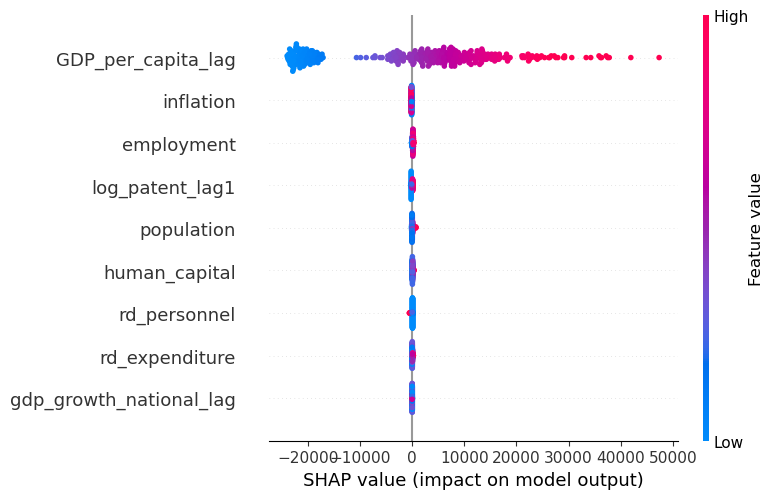

In [246]:
shap.summary_plot(shap_values_pat, X_test_pat)

#### Bar importance plot

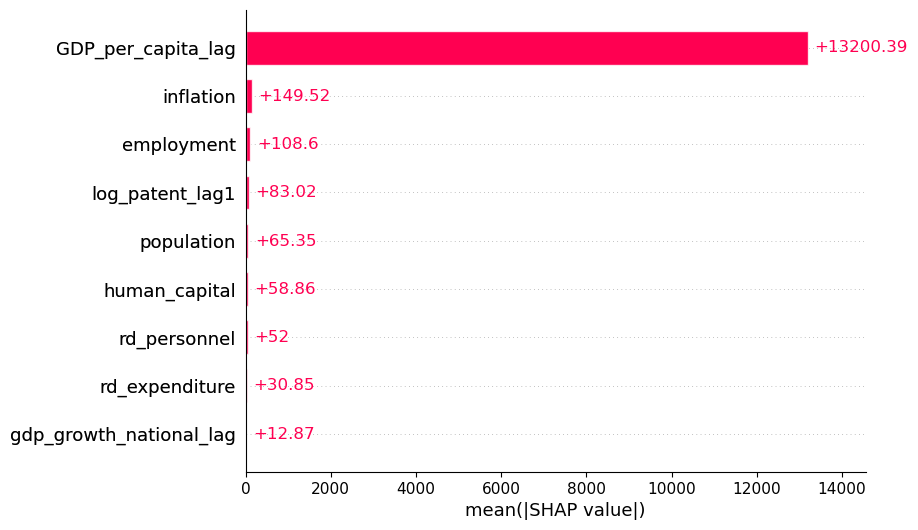

In [247]:
shap.plots.bar(shap_values_pat)

#### Waterfall plot (single observation)

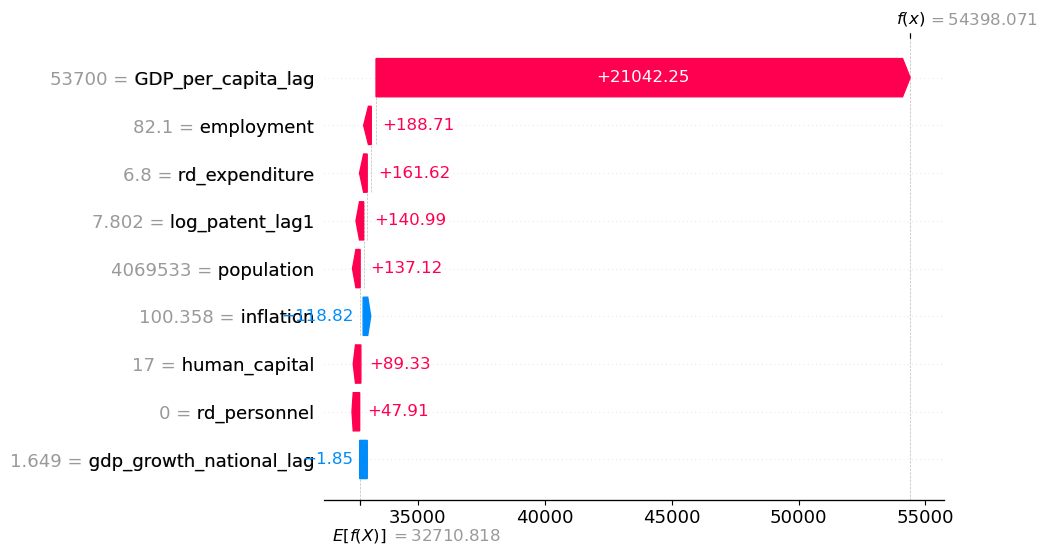

In [248]:
shap.plots.waterfall(shap_values_pat[0])

#### Importance table

In [249]:
importance_pat = pd.Series(
    abs(shap_values_pat.values).mean(axis=0),
    index=X_test_pat.columns
).sort_values(ascending=False)

print(importance_pat)

GDP_per_capita_lag         13200.390667
inflation                    149.515622
employment                   108.597533
log_patent_lag1               83.024991
population                    65.351351
human_capital                 58.864828
rd_personnel                  51.995321
rd_expenditure                30.849865
gdp_growth_national_lag       12.874945
dtype: float64


### SHAP for BASE model (comparison)

In [250]:
explainer_base = shap.Explainer(lr_base, X_train_base)
shap_values_base = explainer_base(X_test_base)

#### Base bar plot only

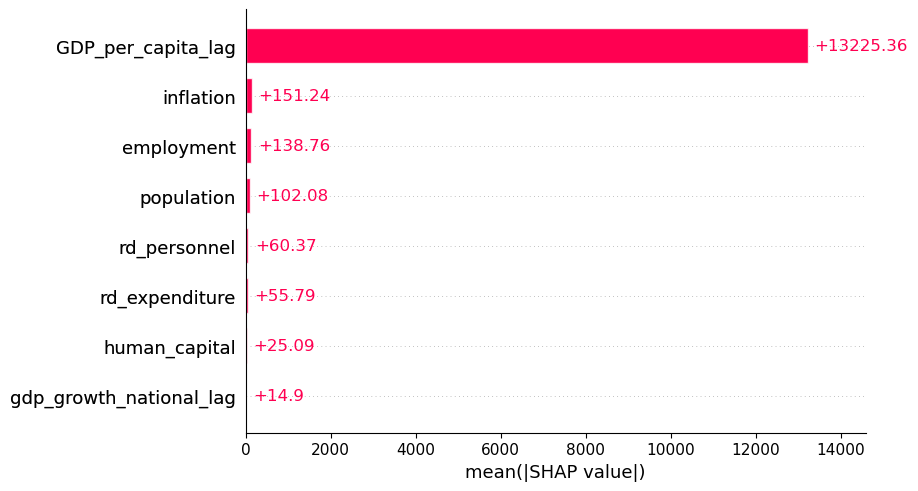

In [251]:
shap.plots.bar(shap_values_base)

#### Compare rankings side by side

In [252]:
importance_base = pd.Series(
    abs(shap_values_base.values).mean(axis=0),
    index=X_test_base.columns
).sort_values(ascending=False)

comparison = pd.DataFrame({
    "Base_Model": importance_base,
    "Patent_Model": importance_pat
})

print(comparison)

                           Base_Model  Patent_Model
GDP_per_capita_lag       13225.363984  13200.390667
employment                 138.756018    108.597533
gdp_growth_national_lag     14.895601     12.874945
human_capital               25.090589     58.864828
inflation                  151.235322    149.515622
log_patent_lag1                   NaN     83.024991
population                 102.075559     65.351351
rd_expenditure              55.786700     30.849865
rd_personnel                60.373505     51.995321


In [253]:
# Keep Patent variable names in their own column (aligned like Base_Variable)

base_sorted = (
    comparison["Base_Model"]
    .sort_values(ascending=False)
    .reset_index()
)

patent_sorted = (
    comparison["Patent_Model"]
    .sort_values(ascending=False)
    .reset_index()
)

# Rename columns
base_sorted.columns = ["Base_Variable", "Base_Model"]
patent_sorted.columns = ["Patent_Variable", "Patent_Model"]

# Combine side by side
comparison_aligned = pd.concat(
    [base_sorted, patent_sorted],
    axis=1
)

print(comparison_aligned)

             Base_Variable    Base_Model          Patent_Variable  \
0       GDP_per_capita_lag  13225.363984       GDP_per_capita_lag   
1                inflation    151.235322                inflation   
2               employment    138.756018               employment   
3               population    102.075559          log_patent_lag1   
4             rd_personnel     60.373505               population   
5           rd_expenditure     55.786700            human_capital   
6            human_capital     25.090589             rd_personnel   
7  gdp_growth_national_lag     14.895601           rd_expenditure   
8          log_patent_lag1           NaN  gdp_growth_national_lag   

   Patent_Model  
0  13200.390667  
1    149.515622  
2    108.597533  
3     83.024991  
4     65.351351  
5     58.864828  
6     51.995321  
7     30.849865  
8     12.874945  


In [254]:
# Rebuild cleanly so Patent_Variable values are on the SAME ROWS as Patent_Model values

# Sort each series independently
base_sorted = comparison["Base_Model"].sort_values(ascending=False).reset_index()
patent_sorted = comparison["Patent_Model"].sort_values(ascending=False).reset_index()

# Rename columns
base_sorted.columns = ["Base_Variable", "Base_Model"]
patent_sorted.columns = ["Patent_Variable", "Patent_Model"]

# IMPORTANT: reset indexes so rows align 0..n
base_sorted = base_sorted.reset_index(drop=True)
patent_sorted = patent_sorted.reset_index(drop=True)

# Concatenate side by side
comparison_fixed = pd.concat([base_sorted, patent_sorted], axis=1)

print(comparison_fixed.to_string(index=False))

          Base_Variable   Base_Model         Patent_Variable  Patent_Model
     GDP_per_capita_lag 13225.363984      GDP_per_capita_lag  13200.390667
              inflation   151.235322               inflation    149.515622
             employment   138.756018              employment    108.597533
             population   102.075559         log_patent_lag1     83.024991
           rd_personnel    60.373505              population     65.351351
         rd_expenditure    55.786700           human_capital     58.864828
          human_capital    25.090589            rd_personnel     51.995321
gdp_growth_national_lag    14.895601          rd_expenditure     30.849865
        log_patent_lag1          NaN gdp_growth_national_lag     12.874945


### Random Forest

In [255]:
# ==========================================================
# SHAP for PATENT RF model
# ==========================================================

explainer_rf_pat = shap.TreeExplainer(best_rf_pat)

shap_values_rf_pat = explainer_rf_pat.shap_values(X_test_pat)

shap_exp_rf_pat = shap.Explanation(
    values=shap_values_rf_pat,
    base_values=np.repeat(explainer_rf_pat.expected_value, len(X_test_pat)),
    data=X_test_pat.values,
    feature_names=X_test_pat.columns
)

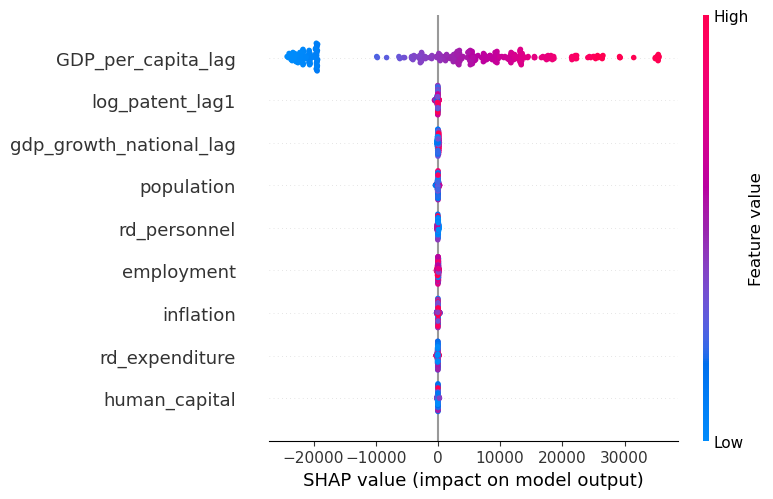

In [256]:
# Summary plot — most important chart
shap.summary_plot(shap_exp_rf_pat, X_test_pat)

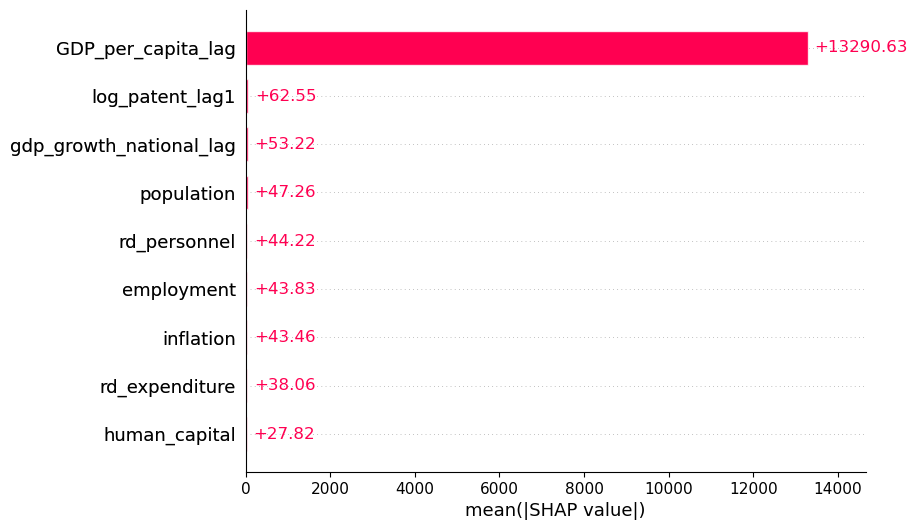

In [257]:
# Bar importance plot
shap.plots.bar(shap_exp_rf_pat)

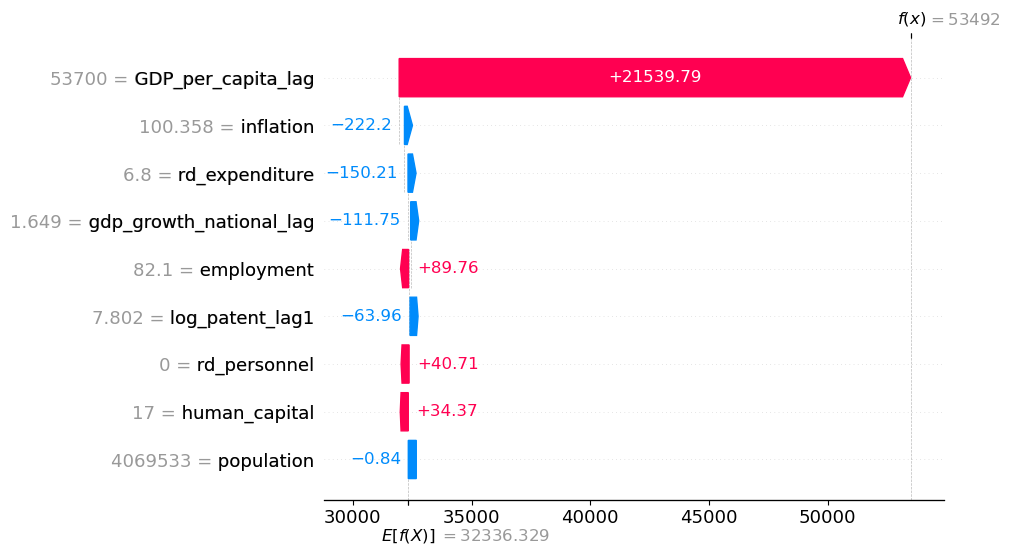

In [258]:
# Waterfall plot — single observation
shap.plots.waterfall(shap_exp_rf_pat[0])

In [259]:
# Importance table — PATENT RF
importance_rf_pat = pd.Series(
    np.abs(shap_exp_rf_pat.values).mean(axis=0),
    index=X_test_pat.columns
).sort_values(ascending=False)

print(importance_rf_pat)

GDP_per_capita_lag         13290.626687
log_patent_lag1               62.549910
gdp_growth_national_lag       53.220454
population                    47.258903
rd_personnel                  44.219287
employment                    43.830618
inflation                     43.464684
rd_expenditure                38.062096
human_capital                 27.821278
dtype: float64


In [260]:
# ==========================================================
# SHAP for BASE RF model
# ==========================================================

explainer_rf_base = shap.TreeExplainer(best_rf_base)

shap_values_rf_base = explainer_rf_base.shap_values(X_test_base)

shap_exp_rf_base = shap.Explanation(
    values=shap_values_rf_base,
    base_values=np.repeat(explainer_rf_base.expected_value, len(X_test_base)),
    data=X_test_base.values,
    feature_names=X_test_base.columns
)

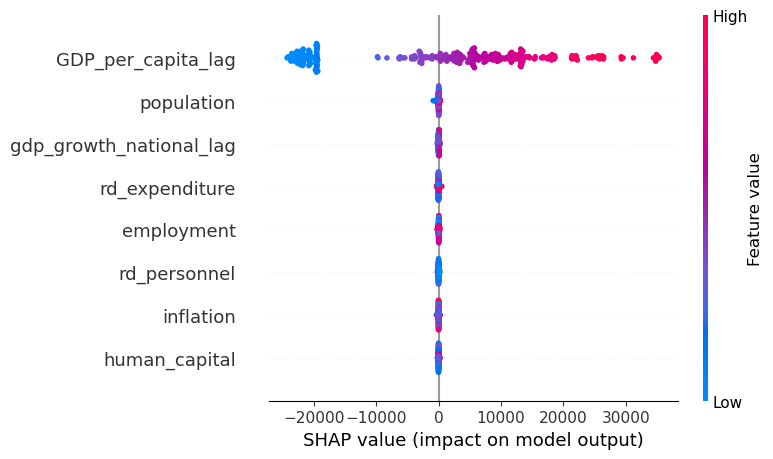

In [261]:
# Summary plot — BASE RF
shap.summary_plot(shap_exp_rf_base, X_test_base)

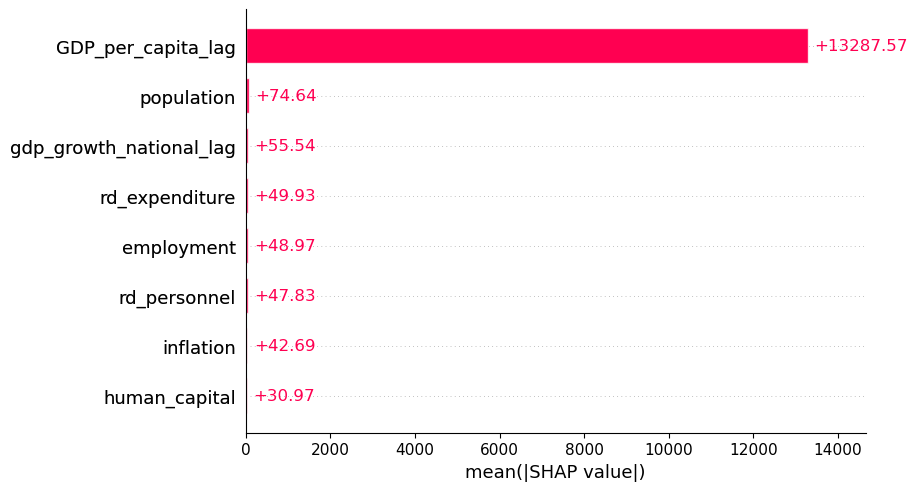

In [262]:
# Bar importance plot — BASE RF
shap.plots.bar(shap_exp_rf_base)

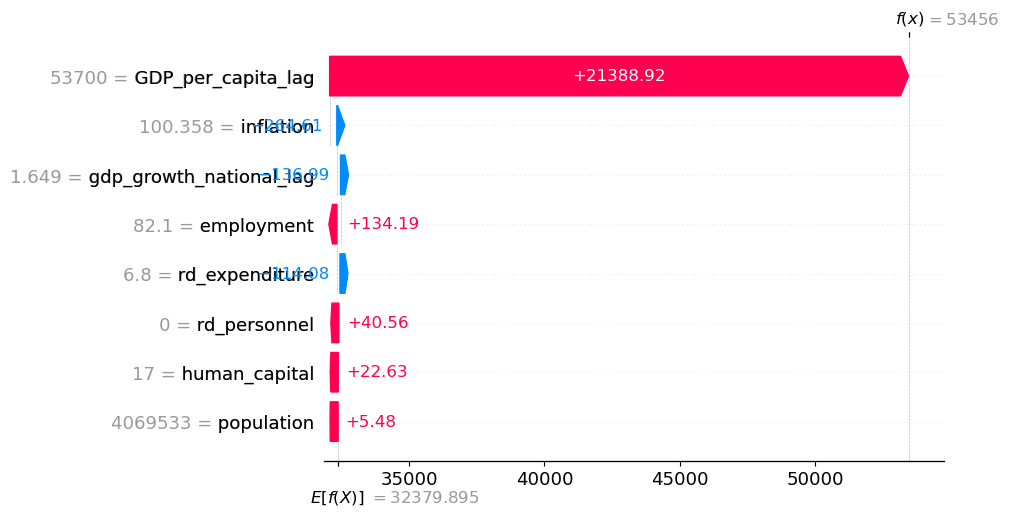

In [263]:
# Waterfall plot — BASE RF
shap.plots.waterfall(shap_exp_rf_base[0])

In [264]:
# Importance table — BASE RF
importance_rf_base = pd.Series(
    np.abs(shap_exp_rf_base.values).mean(axis=0),
    index=X_test_base.columns
).sort_values(ascending=False)

print(importance_rf_base)

GDP_per_capita_lag         13287.573150
population                    74.637250
gdp_growth_national_lag       55.539327
rd_expenditure                49.926200
employment                    48.969629
rd_personnel                  47.830856
inflation                     42.689425
human_capital                 30.974446
dtype: float64


In [265]:
# ==========================================================
# Compare BASE RF vs PATENT RF SHAP importance
# ==========================================================

comparison_rf = pd.DataFrame({
    "Base_Model": importance_rf_base,
    "Patent_Model": importance_rf_pat
})

# Rebuild clearly so variable values are on the SAME ROWS as model values

base_sorted = comparison_rf["Base_Model"].sort_values(ascending=False).reset_index()
patent_sorted = comparison_rf["Patent_Model"].sort_values(ascending=False).reset_index()

base_sorted.columns = ["Base_Variable", "Base_Model"]
patent_sorted.columns = ["Patent_Variable", "Patent_Model"]

base_sorted = base_sorted.reset_index(drop=True)
patent_sorted = patent_sorted.reset_index(drop=True)

comparison_rf_fixed = pd.concat([base_sorted, patent_sorted], axis=1)

print(comparison_rf_fixed.to_string(index=False))

          Base_Variable   Base_Model         Patent_Variable  Patent_Model
     GDP_per_capita_lag 13287.573150      GDP_per_capita_lag  13290.626687
             population    74.637250         log_patent_lag1     62.549910
gdp_growth_national_lag    55.539327 gdp_growth_national_lag     53.220454
         rd_expenditure    49.926200              population     47.258903
             employment    48.969629            rd_personnel     44.219287
           rd_personnel    47.830856              employment     43.830618
              inflation    42.689425               inflation     43.464684
          human_capital    30.974446          rd_expenditure     38.062096
        log_patent_lag1          NaN           human_capital     27.821278


### Gradient Boost

In [266]:
# ==========================================================
# SHAP for PATENT Gradient Boosting model
# ==========================================================

explainer_gb_pat = shap.TreeExplainer(best_gb_pat)

shap_values_gb_pat = explainer_gb_pat.shap_values(X_test_pat)

shap_exp_gb_pat = shap.Explanation(
    values=shap_values_gb_pat,
    base_values=np.repeat(explainer_gb_pat.expected_value, len(X_test_pat)),
    data=X_test_pat.values,
    feature_names=X_test_pat.columns
)

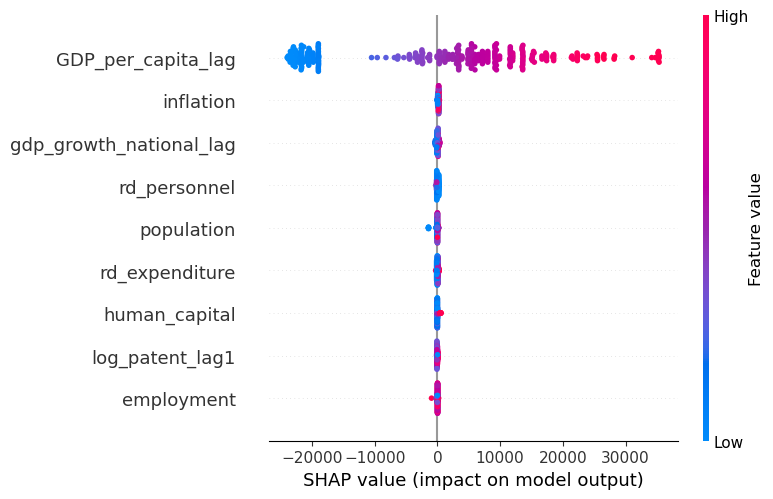

In [267]:
# Summary plot — PATENT GB
shap.summary_plot(shap_exp_gb_pat, X_test_pat)

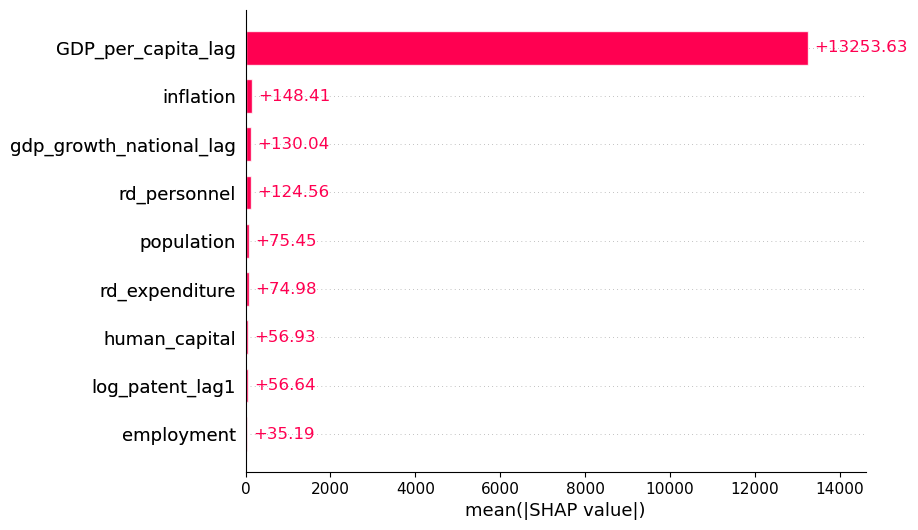

In [268]:
# Bar importance plot — PATENT GB
shap.plots.bar(shap_exp_gb_pat)

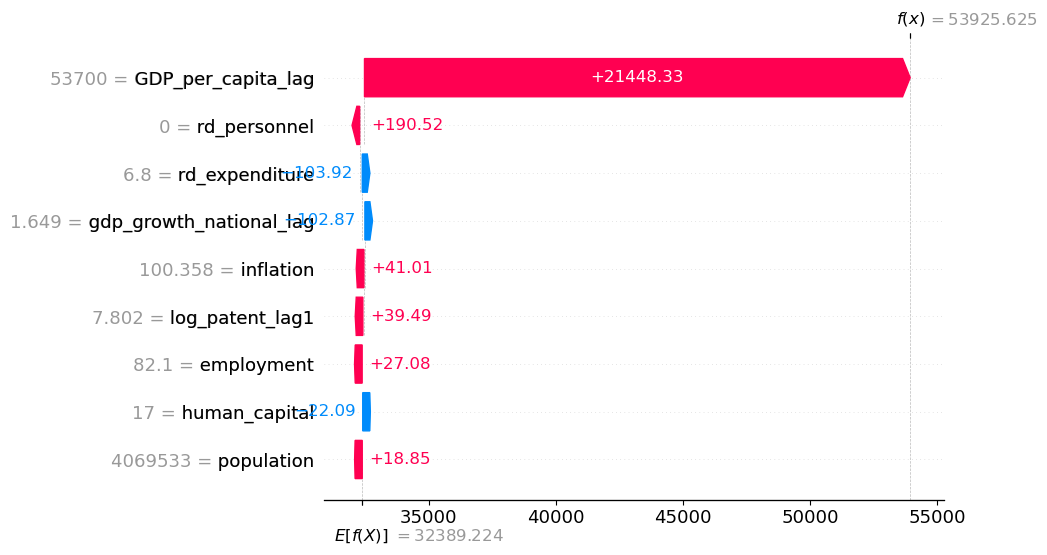

In [269]:
# Waterfall plot — PATENT GB, first observation
shap.plots.waterfall(shap_exp_gb_pat[0])

In [270]:
# Importance table — PATENT GB

importance_gb_pat = pd.Series(
    np.abs(shap_exp_gb_pat.values).mean(axis=0),
    index=X_test_pat.columns
).sort_values(ascending=False)

print(importance_gb_pat)

GDP_per_capita_lag         13253.630215
inflation                    148.408102
gdp_growth_national_lag      130.035764
rd_personnel                 124.558917
population                    75.449486
rd_expenditure                74.975199
human_capital                 56.934636
log_patent_lag1               56.641957
employment                    35.190228
dtype: float64


In [271]:
# ==========================================================
# SHAP for BASE Gradient Boosting model
# ==========================================================

explainer_gb_base = shap.TreeExplainer(best_gb_base)

shap_values_gb_base = explainer_gb_base.shap_values(X_test_base)

shap_exp_gb_base = shap.Explanation(
    values=shap_values_gb_base,
    base_values=np.repeat(explainer_gb_base.expected_value, len(X_test_base)),
    data=X_test_base.values,
    feature_names=X_test_base.columns
)

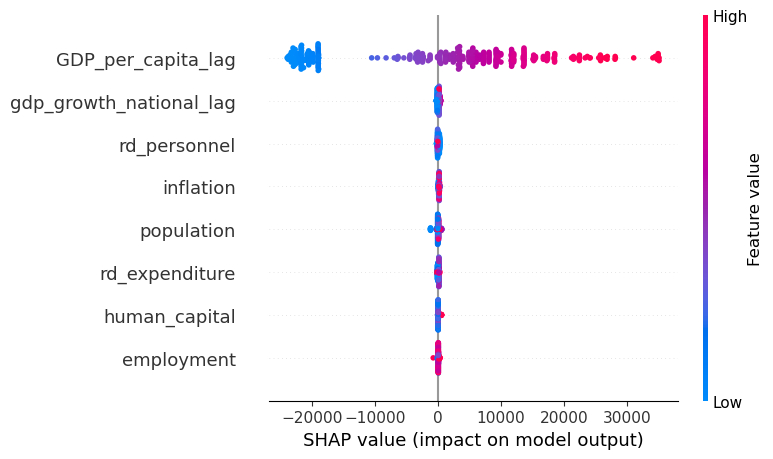

In [272]:
# Summary plot — BASE GB
shap.summary_plot(shap_exp_gb_base, X_test_base)

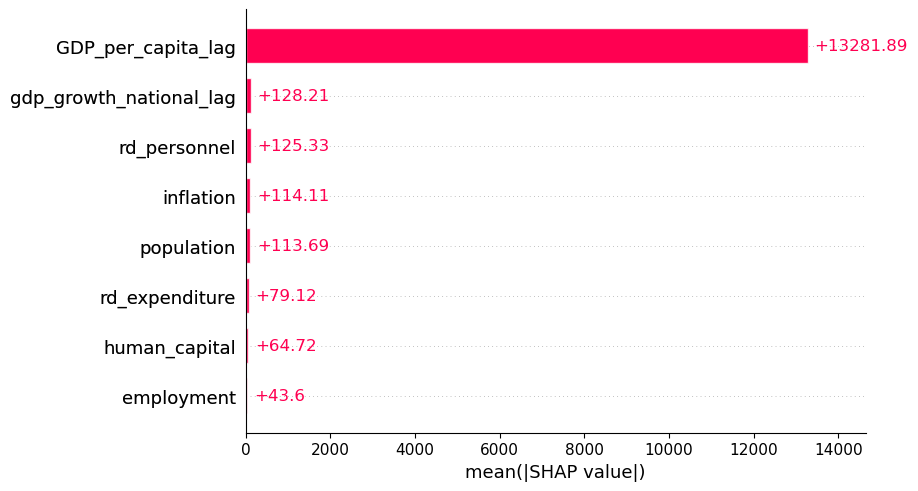

In [273]:
# Bar importance plot — BASE GB
shap.plots.bar(shap_exp_gb_base)

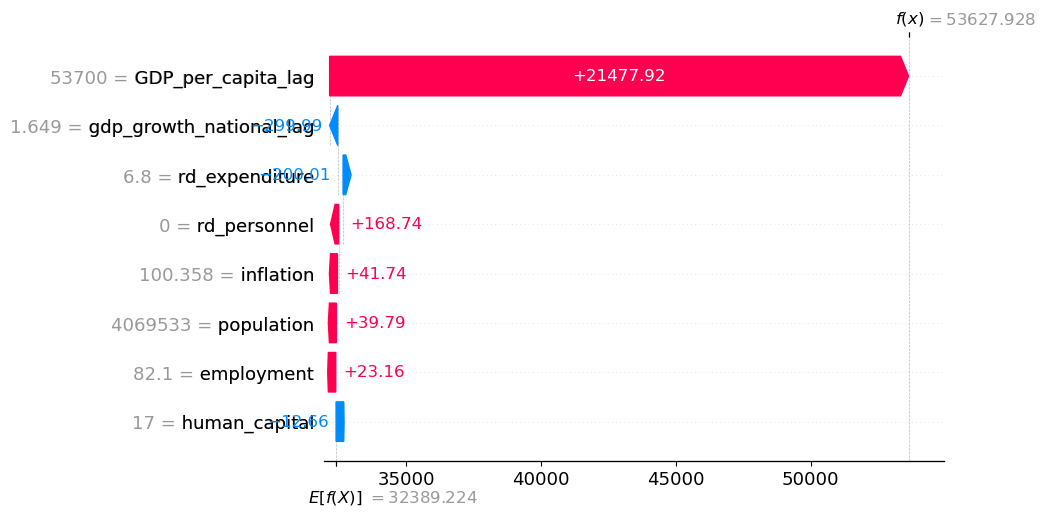

In [274]:
# Waterfall plot — BASE GB, first observation
shap.plots.waterfall(shap_exp_gb_base[0])

In [275]:
# Importance table — BASE GB

importance_gb_base = pd.Series(
    np.abs(shap_exp_gb_base.values).mean(axis=0),
    index=X_test_base.columns
).sort_values(ascending=False)

print(importance_gb_base)

GDP_per_capita_lag         13281.891963
gdp_growth_national_lag      128.208072
rd_personnel                 125.332322
inflation                    114.111533
population                   113.686204
rd_expenditure                79.123789
human_capital                 64.719813
employment                    43.595888
dtype: float64


In [276]:
# ==========================================================
# Compare BASE GB vs PATENT GB SHAP importance
# ==========================================================

comparison_gb = pd.DataFrame({
    "Base_Model": importance_gb_base,
    "Patent_Model": importance_gb_pat
})

base_sorted = comparison_gb["Base_Model"].sort_values(ascending=False).reset_index()
patent_sorted = comparison_gb["Patent_Model"].sort_values(ascending=False).reset_index()

base_sorted.columns = ["Base_Variable", "Base_Model"]
patent_sorted.columns = ["Patent_Variable", "Patent_Model"]

base_sorted = base_sorted.reset_index(drop=True)
patent_sorted = patent_sorted.reset_index(drop=True)

comparison_gb_fixed = pd.concat([base_sorted, patent_sorted], axis=1)

print(comparison_gb_fixed.to_string(index=False))

          Base_Variable   Base_Model         Patent_Variable  Patent_Model
     GDP_per_capita_lag 13281.891963      GDP_per_capita_lag  13253.630215
gdp_growth_national_lag   128.208072               inflation    148.408102
           rd_personnel   125.332322 gdp_growth_national_lag    130.035764
              inflation   114.111533            rd_personnel    124.558917
             population   113.686204              population     75.449486
         rd_expenditure    79.123789          rd_expenditure     74.975199
          human_capital    64.719813           human_capital     56.934636
             employment    43.595888         log_patent_lag1     56.641957
        log_patent_lag1          NaN              employment     35.190228


## Graphs

#### Replication

   Actual_GDP            AR        Linear  RandomForest  GradientBoost
0     30500.0  30616.193887  30499.179665  31140.785245   31495.196402
1     31200.0  30716.331102  30599.445828  31272.105538   30642.148059
2     31400.0  31417.291609  31280.053762  31697.908369   31267.743026
3     31600.0  31617.566040  31492.021341  32023.250397   31495.531155
4     36100.0  35923.466298  35944.506942  35698.058135   36189.978270


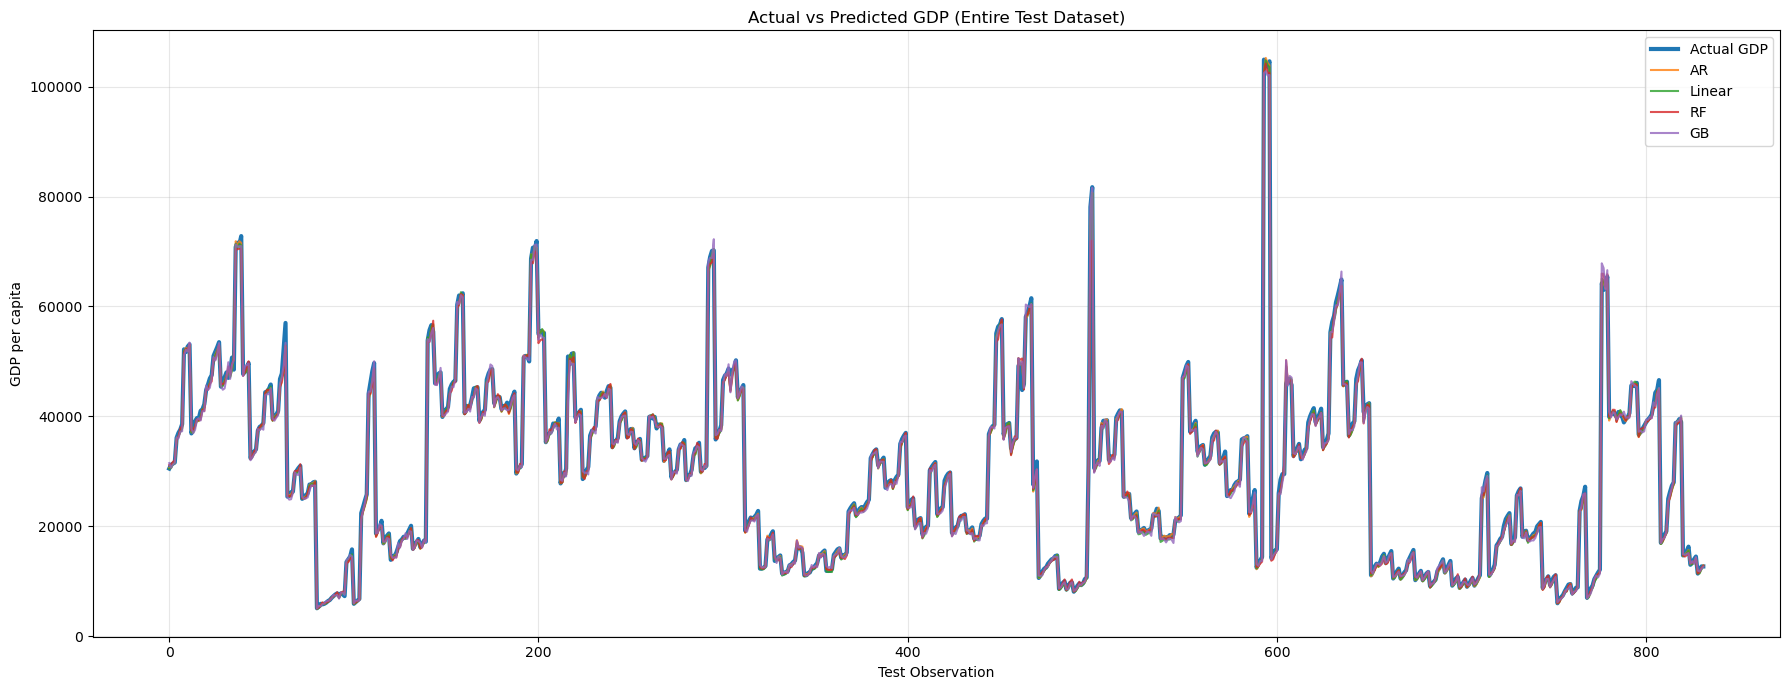

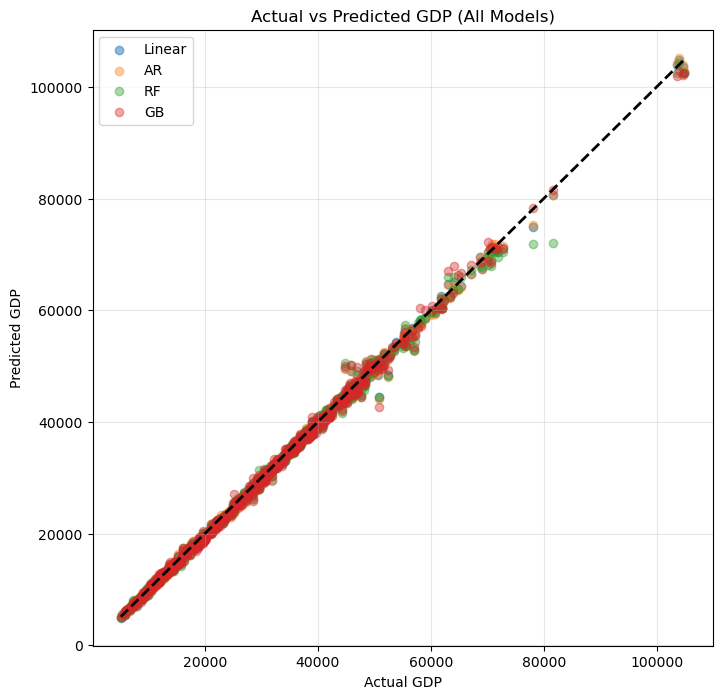

In [277]:
# =====================================================
# COMBINE REPLICATION TEST DATAFRAMES + COMPARE 4 MODELS
# AR, Linear, RF, GB vs Actual GDP_per_capita
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Keep only actual + predictions from each dataframe
df_compare = pd.DataFrame({
    "Actual_GDP": df_ar_test["GDP_per_capita"].values,
    "AR": df_ar_test["pred_ar"].values,
    "Linear": df_lr_test["pred_lr"].values,
    "RandomForest": df_rf_test["pred_rf"].values,
    "GradientBoost": df_gb_test["pred_gb_cv"].values
})

# View first rows
print(df_compare.head())

# =====================================================
# GRAPH 1 — Entire dataset
# =====================================================

plt.figure(figsize=(18,7))

plt.plot(df_compare["Actual_GDP"].values, label="Actual GDP", linewidth=3)
plt.plot(df_compare["AR"].values, label="AR", alpha=0.8)
plt.plot(df_compare["Linear"].values, label="Linear", alpha=0.8)
plt.plot(df_compare["RandomForest"].values, label="RF", alpha=0.8)
plt.plot(df_compare["GradientBoost"].values, label="GB", alpha=0.8)

plt.title("Actual vs Predicted GDP (Entire Test Dataset)")
plt.xlabel("Test Observation")
plt.ylabel("GDP per capita")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# GRAPH 2 — Scatter Actual vs Predicted
# =====================================================

plt.figure(figsize=(8,8))

plt.scatter(df_compare["Actual_GDP"], df_compare["Linear"], alpha=0.5, label="Linear")
plt.scatter(df_compare["Actual_GDP"], df_compare["AR"], alpha=0.4, label="AR")
plt.scatter(df_compare["Actual_GDP"], df_compare["RandomForest"], alpha=0.4, label="RF")
plt.scatter(df_compare["Actual_GDP"], df_compare["GradientBoost"], alpha=0.4, label="GB")

mn = df_compare["Actual_GDP"].min()
mx = df_compare["Actual_GDP"].max()

plt.plot([mn, mx], [mn, mx], "k--", linewidth=2)

plt.xlabel("Actual GDP")
plt.ylabel("Predicted GDP")
plt.title("Actual vs Predicted GDP (All Models)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


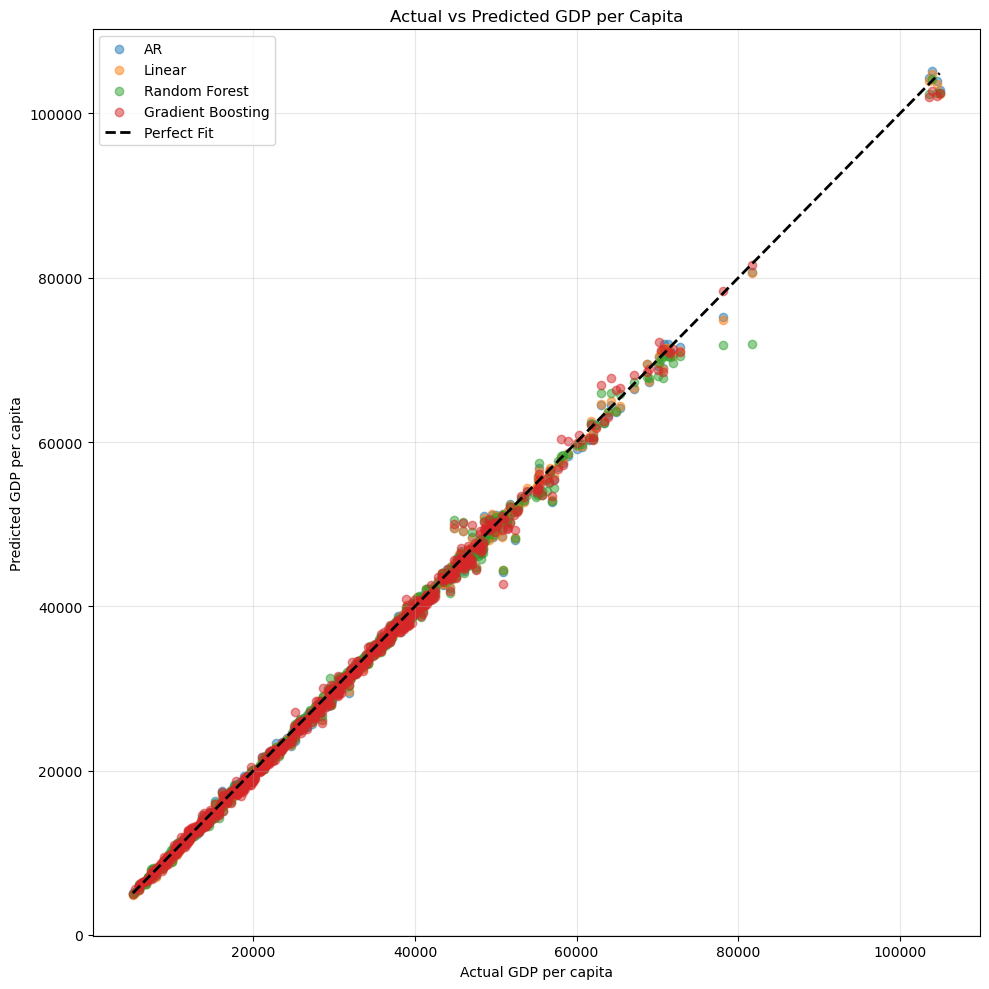

In [278]:
# =====================================================
# SCATTER PLOT — Actual vs Predicted GDP (All Models)
# =====================================================

plt.figure(figsize=(10,10))

plt.scatter(df_compare["Actual_GDP"], df_compare["AR"],
            alpha=0.5, label="AR")

plt.scatter(df_compare["Actual_GDP"], df_compare["Linear"],
            alpha=0.5, label="Linear")

plt.scatter(df_compare["Actual_GDP"], df_compare["RandomForest"],
            alpha=0.5, label="Random Forest")

plt.scatter(df_compare["Actual_GDP"], df_compare["GradientBoost"],
            alpha=0.5, label="Gradient Boosting")

# Perfect prediction line
mn = df_compare["Actual_GDP"].min()
mx = df_compare["Actual_GDP"].max()

plt.plot([mn, mx], [mn, mx], "k--", linewidth=2, label="Perfect Fit")

plt.title("Actual vs Predicted GDP per Capita")
plt.xlabel("Actual GDP per capita")
plt.ylabel("Predicted GDP per capita")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Restricted dataset

In [279]:
# =====================================================
# RESTRICTED DATASET (BASE vs PATENT)
# Compare Linear, RF, GB with and without patents
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Build comparison dataframe
df_restricted = pd.DataFrame({
    "Actual_GDP": y_test_base.values,

    # Linear
    "LR_Base": y_pred_lr_base,
    "LR_Patent": y_pred_lr_pat,

    # Random Forest
    "RF_Base": y_pred_rf_base,
    "RF_Patent": y_pred_rf_pat,

    # Gradient Boosting
    "GB_Base": y_pred_gb_base,
    "GB_Patent": y_pred_gb_pat
})

print(df_restricted.head())

   Actual_GDP       LR_Base     LR_Patent  RF_Base  RF_Patent       GB_Base  \
0     53800.0  54501.008256  54398.070605  53456.0    53492.0  53627.928367   
1     55700.0  53938.935494  53906.412343  53522.0    53399.0  53752.802811   
2     56600.0  56491.489648  56362.964110  57577.0    57081.0  55922.605264   
3     55400.0  56680.618611  56648.520976  58459.0    57632.5  56553.798726   
4     46000.0  46491.108643  46461.972523  45451.0    45418.5  46207.511272   

      GB_Patent  
0  53925.625115  
1  53581.224975  
2  55660.131052  
3  56668.018715  
4  46276.344045  


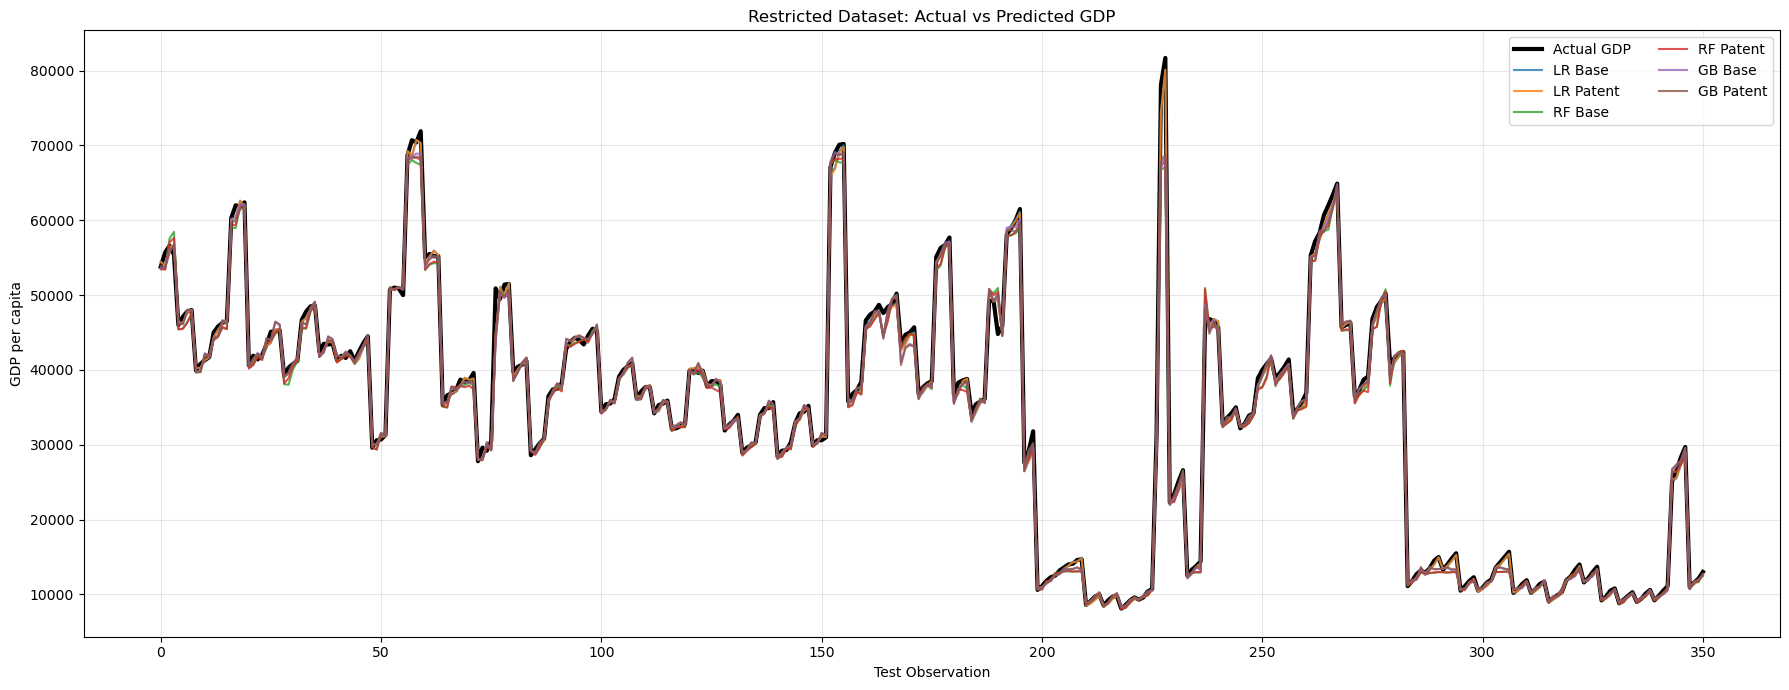

In [280]:
# =====================================================
# GRAPH 1 — Entire Test Dataset
# =====================================================

plt.figure(figsize=(18,7))

plt.plot(df_restricted["Actual_GDP"].values,
         label="Actual GDP", linewidth=3, color="black")

plt.plot(df_restricted["LR_Base"].values, label="LR Base", alpha=0.8)
plt.plot(df_restricted["LR_Patent"].values, label="LR Patent", alpha=0.8)

plt.plot(df_restricted["RF_Base"].values, label="RF Base", alpha=0.8)
plt.plot(df_restricted["RF_Patent"].values, label="RF Patent", alpha=0.8)

plt.plot(df_restricted["GB_Base"].values, label="GB Base", alpha=0.8)
plt.plot(df_restricted["GB_Patent"].values, label="GB Patent", alpha=0.8)

plt.title("Restricted Dataset: Actual vs Predicted GDP")
plt.xlabel("Test Observation")
plt.ylabel("GDP per capita")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

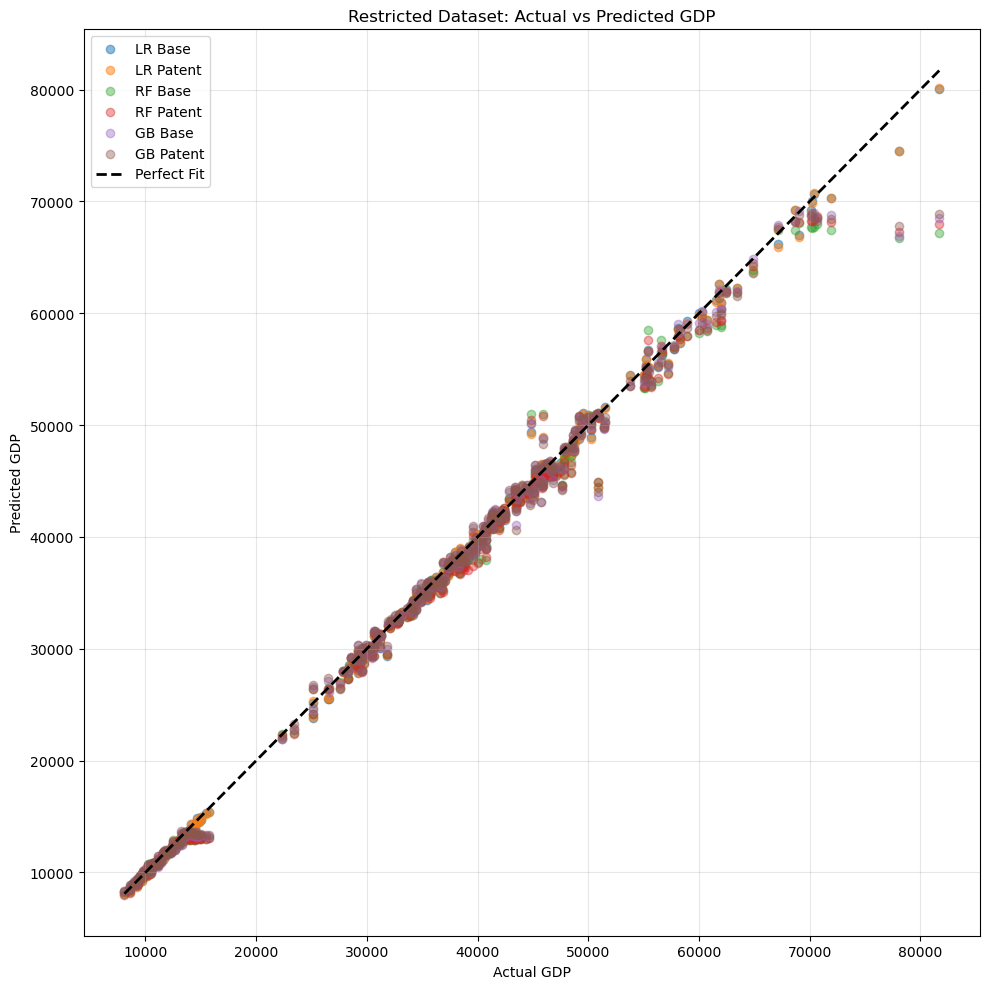

In [281]:
# =====================================================
# GRAPH 2 — Scatter Plot (Base vs Patent versions)
# =====================================================

plt.figure(figsize=(10,10))

plt.scatter(df_restricted["Actual_GDP"], df_restricted["LR_Base"],
            alpha=0.5, label="LR Base")

plt.scatter(df_restricted["Actual_GDP"], df_restricted["LR_Patent"],
            alpha=0.5, label="LR Patent")

plt.scatter(df_restricted["Actual_GDP"], df_restricted["RF_Base"],
            alpha=0.4, label="RF Base")

plt.scatter(df_restricted["Actual_GDP"], df_restricted["RF_Patent"],
            alpha=0.4, label="RF Patent")

plt.scatter(df_restricted["Actual_GDP"], df_restricted["GB_Base"],
            alpha=0.4, label="GB Base")

plt.scatter(df_restricted["Actual_GDP"], df_restricted["GB_Patent"],
            alpha=0.4, label="GB Patent")

mn = df_restricted["Actual_GDP"].min()
mx = df_restricted["Actual_GDP"].max()

plt.plot([mn, mx], [mn, mx], "k--", linewidth=2, label="Perfect Fit")

plt.title("Restricted Dataset: Actual vs Predicted GDP")
plt.xlabel("Actual GDP")
plt.ylabel("Predicted GDP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

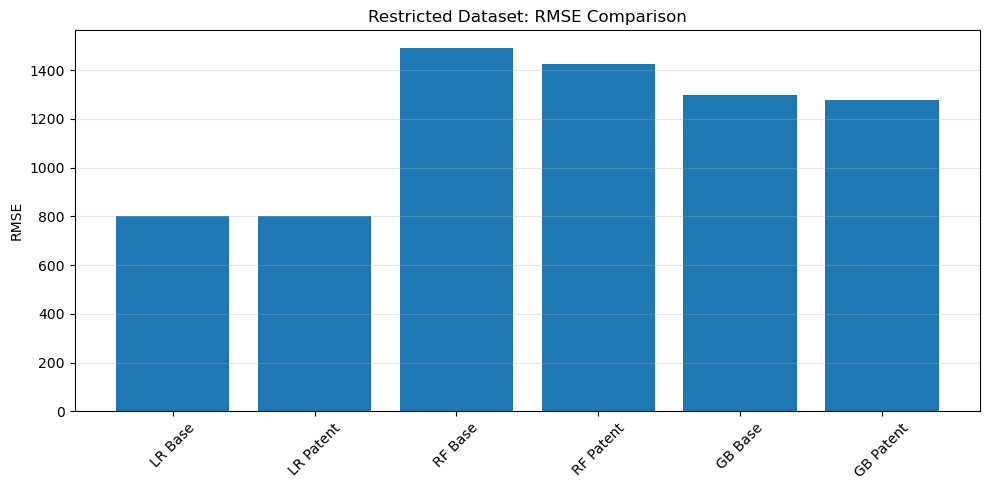

In [282]:
# =====================================================
# GRAPH 3 — RMSE Comparison
# =====================================================

models = [
    "LR Base", "LR Patent",
    "RF Base", "RF Patent",
    "GB Base", "GB Patent"
]

rmse_vals = [
    rmse_lr_base, rmse_lr_pat,
    rmse_rf_base, rmse_rf_pat,
    rmse_gb_base, rmse_gb_pat
]

plt.figure(figsize=(10,5))
plt.bar(models, rmse_vals)

plt.title("Restricted Dataset: RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()